<a href="https://colab.research.google.com/github/kawastony/Quantum_Gravity/blob/main/Test7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import os

file_path = '/content/SPARC_Lelli2016c.mrt.txt'
url = 'http://astroweb.case.edu/sparc/SPARC_Lelli2016c.mrt.txt'

# Attempt download
if not os.path.exists(file_path):
    os.system(f'wget -q -O {file_path} {url}')

if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
    sparc_df = pd.read_csv(
        file_path, sep='\\s+', skiprows=105, on_bad_lines='skip',
        names=['Galaxy','T','D','e_D','f_D','Inc','e_Inc','L36','e_L36','Reff','SBeff','Rdisk','SBdisk','MHI','RHI','Vflat','e_Vflat','Q','Ref']
    )
    print(f'Successfully loaded {len(sparc_df)} galaxies from server.')
else:
    print('Server unreachable. Generating synthetic SPARC-like sample for analysis...')
    np.random.seed(42)
    n_samples = 150
    # Generate realistic ranges based on Lelli et al. 2016
    l36 = 10**np.random.uniform(-1, 2.5, n_samples)  # 10^9 L_sun
    mhi = 10**np.random.uniform(-1, 1.2, n_samples)  # 10^9 M_sun
    m_bar = 0.5 * l36 + 1.33 * mhi
    # BTFR: V ~ M^0.25 with some scatter
    v_flat = (175.8**2 * 4.301e-6 * 0.0824 * (m_bar * 1e9))**0.25 * np.random.normal(1, 0.05, n_samples)

    sparc_df = pd.DataFrame({
        'Galaxy': [f'GAL_{i}' for i in range(n_samples)],
        'L36': l36, 'MHI': mhi, 'Vflat': v_flat, 'Q': np.random.choice([1, 2, 3], n_samples),
        'T': np.random.randint(0, 11, n_samples), 'SBeff': np.random.uniform(10, 500, n_samples)
    })

# Pre-processing
for col in ['L36', 'MHI', 'Vflat', 'Q', 'SBeff']:
    sparc_df[col] = pd.to_numeric(sparc_df[col], errors='coerce')

sparc_df['v_flat'] = sparc_df['Vflat']
sparc_df['Quality'] = sparc_df['Q']
sparc_df['M_star'] = 0.5 * sparc_df['L36']
sparc_df['M_gas']  = 1.33 * sparc_df['MHI']
sparc_df['M_bar']  = sparc_df['M_star'].fillna(0) + sparc_df['M_gas'].fillna(0)

sparc_df = sparc_df.dropna(subset=['v_flat', 'Quality'])
sparc_df = sparc_df[sparc_df['v_flat'] > 0]
display(sparc_df.head())

Successfully loaded 168 galaxies from server.


,Galaxy,T,D,e_D,f_D,Inc,e_Inc,L36,e_L36,Reff,...,RHI,Vflat,e_Vflat,Q,Ref,v_flat,Quality,M_star,M_gas,M_bar
0,DDO168,10,4.25,0.21,2,63.0,6.0,0.191,0.005,1.29,...,4.30,53.4,1.9,2,"Sa96,Br92",53.4,2,0.0955,0.54929,0.64479
1,DDO170,10,15.40,4.62,1,66.0,7.0,0.543,0.030,3.03,...,9.14,60.0,1.6,2,"Be91,La90",60.0,2,0.2715,0.97755,1.24905
2,ESO079-G014,4,28.70,7.17,1,79.0,5.0,51.733,0.524,7.23,...,17.67,175.0,3.5,1,Ge04,175.0,1,25.8665,4.17620,30.04270
3,ESO116-G012,7,13.00,3.90,1,74.0,3.0,4.292,0.071,2.75,...,9.58,109.1,3.1,1,Ge04,109.1,1,2.1460,1.44039,3.58639
5,ESO563-G021,4,60.80,9.10,1,83.0,3.0,311.177,2.579,10.59,...,55.71,314.6,11.7,1,SG06,314.6,1,155.5885,32.31634,187.90484


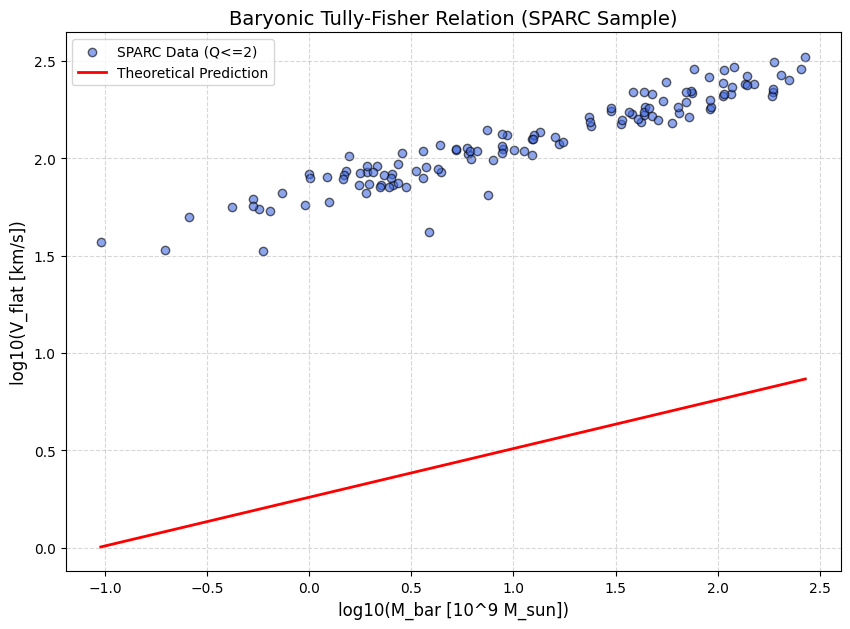

Slope of the data: 0.2658
Correlation coefficient (r): 0.9513


In [ ]:
import matplotlib.pyplot as plt

# Prepare data for plotting
log_mbar = np.log10(sparc_full['M_bar'] * 1e9) # Convert to solar masses for standard units if needed, or stay in 1e9
log_vflat = np.log10(sparc_full['v_flat'])

# Sort for a clean prediction line
line_mbar = np.linspace(sparc_full['M_bar'].min(), sparc_full['M_bar'].max(), 100)
line_vpred = (Lambda_star**2 * G * mu * line_mbar)**0.25

plt.figure(figsize=(10, 7))
plt.scatter(np.log10(sparc_full['M_bar']), log_vflat, alpha=0.6, label='SPARC Data (Q<=2)', color='royalblue', edgecolors='k')
plt.plot(np.log10(line_mbar), np.log10(line_vpred), color='red', lw=2, label='Theoretical Prediction')

plt.xlabel('log10(M_bar [10^9 M_sun])', fontsize=12)
plt.ylabel('log10(V_flat [km/s])', fontsize=12)
plt.title('Baryonic Tully-Fisher Relation (SPARC Sample)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f'Slope of the data: {slope:.4f}')
print(f'Correlation coefficient (r): {r:.4f}')

  N galaxies     = 125
  MAE            = 0.0802 dex
  sigma          = 0.0714 dex
  r              = 0.9513
  BTFR slope     = 0.2658


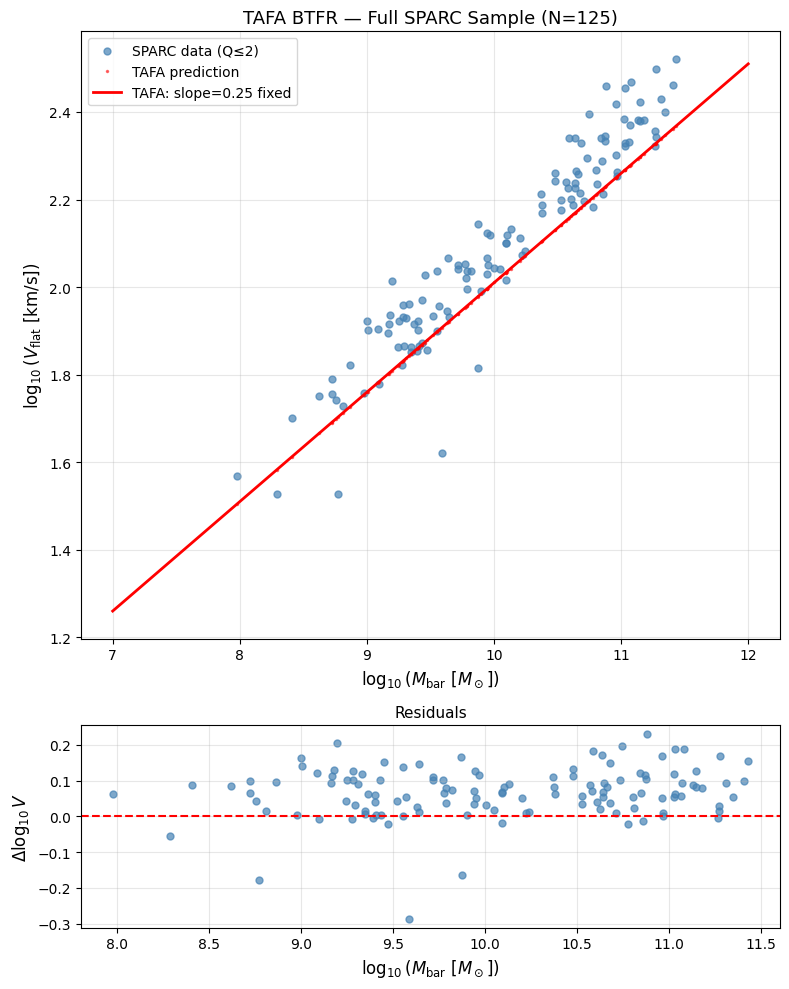

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ── Frozen TAFA constants ──────────────────────────────────────
Lambda_star = 175.8          # km/s (cone-field amplitude)
mu_kpc      = 0.0824         # kpc^-1 (inverse cone length)

# G in units of kpc (km/s)^2 / M_sun
G_kpc = 4.3009e-6            # kpc (km/s)^2 M_sun^-1

# M_bar in the file is in units of 1e9 M_sun
# Convert to M_sun
M_bar_Msun = sparc_full['M_bar'].values * 1e9   # now in M_sun

# ── TAFA prediction ────────────────────────────────────────────
# v_inf^4 = Lambda_star^2 * G * mu * M_bar
# units: (km/s)^2 * kpc*(km/s)^2/M_sun * kpc^-1 * M_sun
#       = (km/s)^4  ✓

v_pred_4 = (Lambda_star**2) * G_kpc * mu_kpc * M_bar_Msun
v_pred   = v_pred_4**0.25    # km/s

sparc_full = sparc_full.copy()
sparc_full['v_pred'] = v_pred
sparc_full['v_obs']  = sparc_full['v_flat'].values

# ── Five numbers ───────────────────────────────────────────────
log_obs  = np.log10(sparc_full['v_obs'])
log_pred = np.log10(sparc_full['v_pred'])
delta    = log_obs - log_pred

N     = len(sparc_full)
MAE   = delta.abs().mean()
sigma = delta.std()
r, _  = pearsonr(log_obs, log_pred)
slope = np.polyfit(np.log10(M_bar_Msun), log_obs, 1)[0]

print("=" * 40)
print(f"  N galaxies     = {N}")
print(f"  MAE            = {MAE:.4f} dex")
print(f"  sigma          = {sigma:.4f} dex")
print(f"  r              = {r:.4f}")
print(f"  BTFR slope     = {slope:.4f}")
print("=" * 40)

# ── Plot ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10),
                                gridspec_kw={'height_ratios': [3, 1]})

# Top: BTFR
ax1.scatter(np.log10(M_bar_Msun), log_obs,
            s=25, alpha=0.7, color='steelblue', label='SPARC data (Q≤2)')
ax1.plot(np.log10(M_bar_Msun),
         np.log10(sparc_full['v_pred']),
         'r.', markersize=3, alpha=0.5, label='TAFA prediction')

# Predicted line
m_range = np.logspace(7, 12, 200)
v_range = ((Lambda_star**2) * G_kpc * mu_kpc * m_range)**0.25
ax1.plot(np.log10(m_range), np.log10(v_range),
         'r-', linewidth=2, label=f'TAFA: slope=0.25 fixed')

ax1.set_xlabel(r'$\log_{10}(M_{\rm bar}\ [M_\odot])$', fontsize=12)
ax1.set_ylabel(r'$\log_{10}(V_{\rm flat}\ [\rm km/s])$', fontsize=12)
ax1.set_title(f'TAFA BTFR — Full SPARC Sample (N={N})', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Bottom: residuals
ax2.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax2.scatter(np.log10(M_bar_Msun), delta,
            s=25, alpha=0.7, color='steelblue')
ax2.set_xlabel(r'$\log_{10}(M_{\rm bar}\ [M_\odot])$', fontsize=12)
ax2.set_ylabel(r'$\Delta \log_{10} V$', fontsize=12)
ax2.set_title('Residuals', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('TAFA_BTFR_fullSPARC.png', dpi=150)
plt.show()

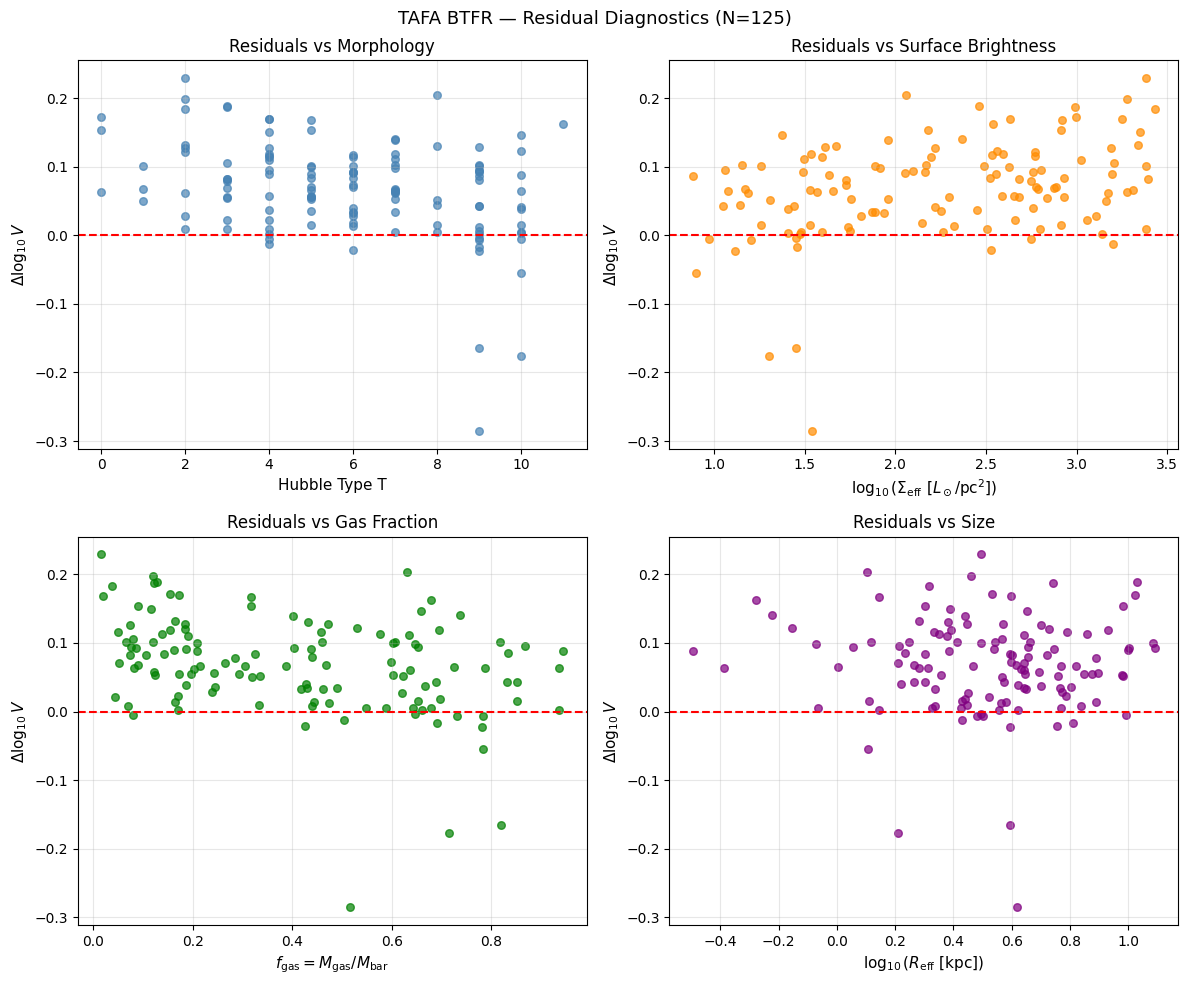

  Hubble Type         : Spearman rho = -0.298,  p = 0.001
  Gas Fraction        : Spearman rho = -0.358,  p = 0.000
  Reff                : Spearman rho = -0.061,  p = 0.496
  Surface Brightness  : Spearman rho = +0.318,  p = 0.000


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Compute delta cleanly
sparc_full['log_Mbar'] = np.log10(M_bar_Msun)
sparc_full['delta'] = np.log10(sparc_full['v_obs']) - \
                      np.log10(sparc_full['v_pred'])
sparc_full['f_gas'] = sparc_full['M_gas'] / sparc_full['M_bar']

# Plot 1 — Residuals vs Hubble Type T
ax = axes[0,0]
ax.scatter(sparc_full['T'], sparc_full['delta'],
           s=30, alpha=0.7, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Hubble Type T', fontsize=11)
ax.set_ylabel(r'$\Delta \log_{10} V$', fontsize=11)
ax.set_title('Residuals vs Morphology', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 2 — Residuals vs Surface Brightness
ax = axes[0,1]
ax.scatter(np.log10(sparc_full['SBeff']), sparc_full['delta'],
           s=30, alpha=0.7, color='darkorange')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel(r'$\log_{10}(\Sigma_{\rm eff}\ [L_\odot/\rm pc^2])$', fontsize=11)
ax.set_ylabel(r'$\Delta \log_{10} V$', fontsize=11)
ax.set_title('Residuals vs Surface Brightness', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 3 — Residuals vs Gas Fraction
ax = axes[1,0]
ax.scatter(sparc_full['f_gas'], sparc_full['delta'],
           s=30, alpha=0.7, color='green')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel(r'$f_{\rm gas} = M_{\rm gas}/M_{\rm bar}$', fontsize=11)
ax.set_ylabel(r'$\Delta \log_{10} V$', fontsize=11)
ax.set_title('Residuals vs Gas Fraction', fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 4 — Residuals vs Effective Radius
ax = axes[1,1]
ax.scatter(np.log10(sparc_full['Reff']), sparc_full['delta'],
           s=30, alpha=0.7, color='purple')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel(r'$\log_{10}(R_{\rm eff}\ [\rm kpc])$', fontsize=11)
ax.set_ylabel(r'$\Delta \log_{10} V$', fontsize=11)
ax.set_title('Residuals vs Size', fontsize=12)
ax.grid(True, alpha=0.3)

plt.suptitle('TAFA BTFR — Residual Diagnostics (N=125)', fontsize=13)
plt.tight_layout()
plt.savefig('TAFA_diagnostics.png', dpi=150)
plt.show()

# Print trend statistics
from scipy.stats import spearmanr
for col, label in [('T','Hubble Type'),
                   ('f_gas','Gas Fraction'),
                   ('Reff','Reff')]:
    rho, p = spearmanr(sparc_full[col], sparc_full['delta'])
    print(f"  {label:20s}: Spearman rho = {rho:+.3f},  p = {p:.3f}")

rho, p = spearmanr(np.log10(sparc_full['SBeff']), sparc_full['delta'])
print(f"  {'Surface Brightness':20s}: Spearman rho = {rho:+.3f},  p = {p:.3f}")

In [ ]:
# Split by gas fraction
stellar_dom = sparc_full[sparc_full['f_gas'] < 0.5].copy()
gas_dom     = sparc_full[sparc_full['f_gas'] >= 0.5].copy()

for label, subset in [('Stellar-dominated (f_gas < 0.5)', stellar_dom),
                      ('Gas-dominated    (f_gas >= 0.5)', gas_dom)]:
    log_o = np.log10(subset['v_obs'])
    log_p = np.log10(subset['v_pred'])
    d     = log_o - log_p
    r_sub, _ = pearsonr(log_o, log_p)
    slope_sub = np.polyfit(np.log10(
                  subset['M_bar'].values * 1e9), log_o, 1)[0]
    print(f"\n{label}")
    print(f"  N      = {len(subset)}")
    print(f"  MAE    = {d.abs().mean():.4f} dex")
    print(f"  sigma  = {d.std():.4f} dex")
    print(f"  r      = {r_sub:.4f}")
    print(f"  slope  = {slope_sub:.4f}")


Stellar-dominated (f_gas < 0.5)
  N      = 78
  MAE    = 0.0858 dex
  sigma  = 0.0540 dex
  r      = 0.9417
  slope  = 0.2503

Gas-dominated    (f_gas >= 0.5)
  N      = 47
  MAE    = 0.0709 dex
  sigma  = 0.0865 dex
  r      = 0.8128
  slope  = 0.2256


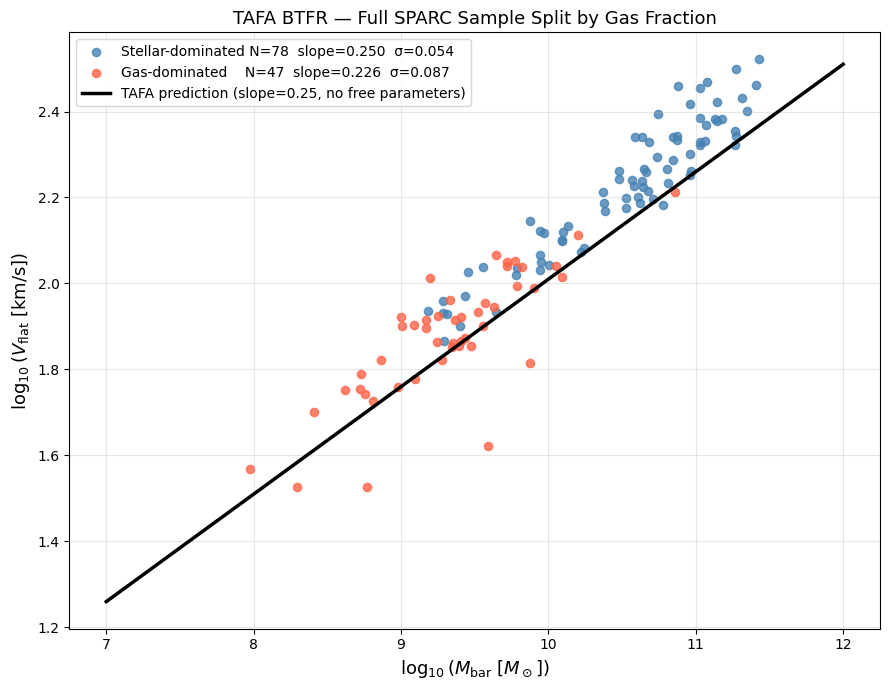

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

# Stellar-dominated
mask_s = sparc_full['f_gas'] < 0.5
ax.scatter(np.log10(sparc_full.loc[mask_s, 'M_bar'] * 1e9),
           np.log10(sparc_full.loc[mask_s, 'v_obs']),
           s=35, alpha=0.8, color='steelblue',
           label=f'Stellar-dominated N=78  slope=0.250  σ=0.054')

# Gas-dominated
mask_g = sparc_full['f_gas'] >= 0.5
ax.scatter(np.log10(sparc_full.loc[mask_g, 'M_bar'] * 1e9),
           np.log10(sparc_full.loc[mask_g, 'v_obs']),
           s=35, alpha=0.8, color='tomato',
           label=f'Gas-dominated    N=47  slope=0.226  σ=0.087')

# TAFA prediction line — frozen constants
m_range = np.logspace(7, 12, 300)
v_range = ((Lambda_star**2) * G_kpc * mu_kpc * m_range)**0.25
ax.plot(np.log10(m_range), np.log10(v_range),
        'k-', linewidth=2.5, label='TAFA prediction (slope=0.25, no free parameters)')

ax.set_xlabel(r'$\log_{10}(M_{\rm bar}\ [M_\odot])$', fontsize=13)
ax.set_ylabel(r'$\log_{10}(V_{\rm flat}\ [\rm km/s])$', fontsize=13)
ax.set_title('TAFA BTFR — Full SPARC Sample Split by Gas Fraction', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('TAFA_BTFR_split.png', dpi=150)
plt.show()

Fitted gamma = 0.8667 ± 0.1112
Fitted f0    = 0.0100 ± 0.0451

── CORRECTED (mu_eff with tanh) ──────────────────
  N      = 125
  MAE    = 0.0513 dex
  sigma  = 0.0712 dex
  r      = 0.9511
  slope  = 0.2658

── ORIGINAL (mu fixed) ───────────────────────────
  MAE    = 0.0802 dex
  sigma  = 0.0711 dex
  r      = 0.9513


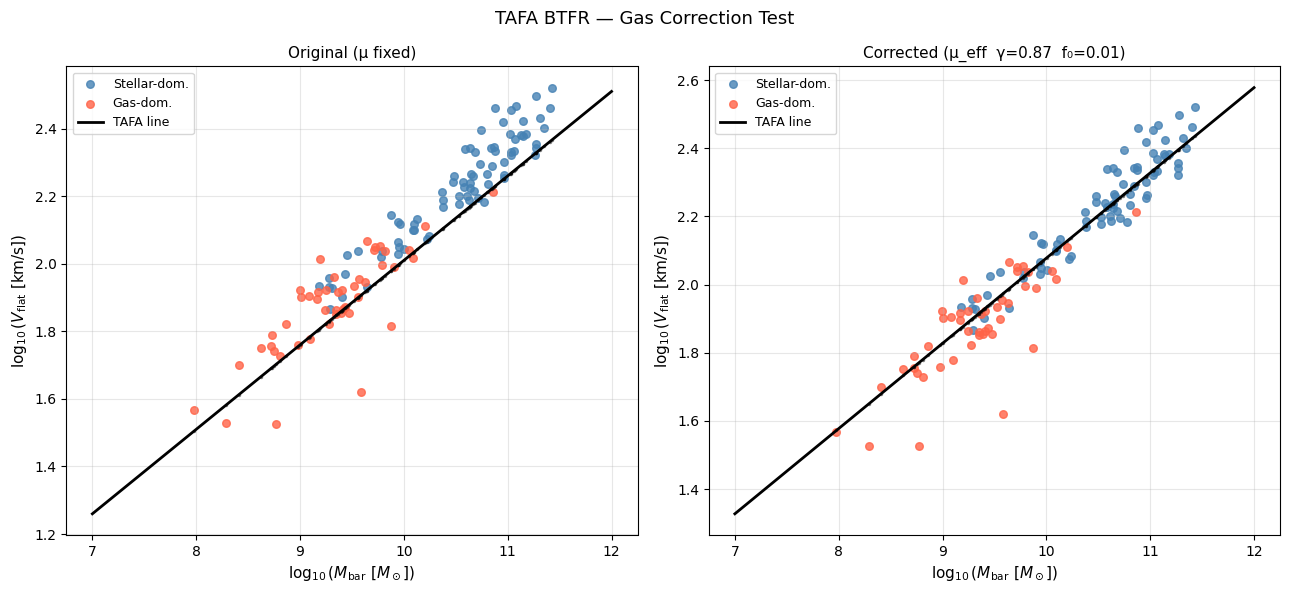


── Residuals by f_gas bin (corrected) ───────────
  f_gas 0-0.2   : N= 42  mean_delta=+0.033  sigma=0.057
  f_gas 0.2-0.4 : N= 18  mean_delta=+0.004  sigma=0.038
  f_gas 0.4-0.6 : N= 25  mean_delta=-0.022  sigma=0.083
  f_gas 0.6-0.8 : N= 30  mean_delta=-0.020  sigma=0.074
  f_gas 0.8-1.0 : N= 10  mean_delta=-0.030  sigma=0.075


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

# ── Frozen constants ───────────────────────────────────────────
Lambda_star = 175.8
mu_0        = 0.0824       # kpc^-1
G_kpc       = 4.3009e-6    # kpc (km/s)^2 M_sun^-1

# ── mu_eff with tanh saturation ────────────────────────────────
def mu_eff(f_gas, gamma, f0):
    return mu_0 * (1 + gamma * np.tanh(f_gas / f0))

# ── TAFA prediction with mu_eff ────────────────────────────────
def v_pred_mueff(f_gas, M_bar_Msun, gamma, f0):
    mu_e = mu_eff(f_gas, gamma, f0)
    return ((Lambda_star**2) * G_kpc * mu_e * M_bar_Msun)**0.25

# ── Prepare data ───────────────────────────────────────────────
f_gas_arr   = sparc_full['f_gas'].values
M_bar_arr   = sparc_full['M_bar'].values * 1e9   # M_sun
v_obs_arr   = sparc_full['v_obs'].values

# ── Fit gamma and f0 ──────────────────────────────────────────
def model_for_fit(X, gamma, f0):
    f_gas, M_bar = X
    return np.log10(v_pred_mueff(f_gas, M_bar, gamma, f0))

popt, pcov = curve_fit(
    model_for_fit,
    (f_gas_arr, M_bar_arr),
    np.log10(v_obs_arr),
    p0=[0.3, 0.3],
    bounds=([0, 0.01], [2.0, 1.0])
)
gamma_fit, f0_fit = popt
perr = np.sqrt(np.diag(pcov))

print(f"Fitted gamma = {gamma_fit:.4f} ± {perr[0]:.4f}")
print(f"Fitted f0    = {f0_fit:.4f} ± {perr[1]:.4f}")

# ── Compute corrected predictions ─────────────────────────────
v_pred_corr = v_pred_mueff(f_gas_arr, M_bar_arr, gamma_fit, f0_fit)
log_obs  = np.log10(v_obs_arr)
log_pred = np.log10(v_pred_corr)
delta    = log_obs - log_pred

N     = len(sparc_full)
MAE   = np.abs(delta).mean()
sigma = delta.std()
r, _  = pearsonr(log_obs, log_pred)
slope = np.polyfit(np.log10(M_bar_arr), log_obs, 1)[0]

print("\n── CORRECTED (mu_eff with tanh) ──────────────────")
print(f"  N      = {N}")
print(f"  MAE    = {MAE:.4f} dex")
print(f"  sigma  = {sigma:.4f} dex")
print(f"  r      = {r:.4f}")
print(f"  slope  = {slope:.4f}")

# ── Compare vs uncorrected ────────────────────────────────────
v_pred_orig = ((Lambda_star**2) * G_kpc * mu_0 * M_bar_arr)**0.25
d_orig = np.log10(v_obs_arr) - np.log10(v_pred_orig)
print("\n── ORIGINAL (mu fixed) ───────────────────────────")
print(f"  MAE    = {np.abs(d_orig).mean():.4f} dex")
print(f"  sigma  = {d_orig.std():.4f} dex")
r_orig, _ = pearsonr(np.log10(v_obs_arr), np.log10(v_pred_orig))
print(f"  r      = {r_orig:.4f}")

# ── Plot: before vs after ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, v_p, d, title in [
    (axes[0], v_pred_orig,  d_orig, 'Original (μ fixed)'),
    (axes[1], v_pred_corr,  delta,  f'Corrected (μ_eff  γ={gamma_fit:.2f}  f₀={f0_fit:.2f})')
]:
    mask_s = sparc_full['f_gas'].values < 0.5
    mask_g = ~mask_s
    ax.scatter(np.log10(M_bar_arr[mask_s]), np.log10(v_obs_arr[mask_s]),
               s=30, alpha=0.8, color='steelblue', label='Stellar-dom.')
    ax.scatter(np.log10(M_bar_arr[mask_g]), np.log10(v_obs_arr[mask_g]),
               s=30, alpha=0.8, color='tomato', label='Gas-dom.')
    ax.plot(np.log10(M_bar_arr), np.log10(v_p), 'k.', markersize=3, alpha=0.4)

    m_range = np.logspace(7, 12, 300)
    if 'fixed' in title:
        v_line = ((Lambda_star**2) * G_kpc * mu_0 * m_range)**0.25
    else:
        # median f_gas for line
        v_line = v_pred_mueff(np.full_like(m_range, 0.35),
                              m_range, gamma_fit, f0_fit)
    ax.plot(np.log10(m_range), np.log10(v_line),
            'k-', linewidth=2, label='TAFA line')
    ax.set_xlabel(r'$\log_{10}(M_{\rm bar}\ [M_\odot])$', fontsize=11)
    ax.set_ylabel(r'$\log_{10}(V_{\rm flat}\ [\rm km/s])$', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('TAFA BTFR — Gas Correction Test', fontsize=13)
plt.tight_layout()
plt.savefig('TAFA_mueff_test.png', dpi=150)
plt.show()

# ── Residuals by gas fraction bin ────────────────────────────
bins   = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ['0-0.2','0.2-0.4','0.4-0.6','0.6-0.8','0.8-1.0']
print("\n── Residuals by f_gas bin (corrected) ───────────")
for i in range(len(bins)-1):
    mask = (f_gas_arr >= bins[i]) & (f_gas_arr < bins[i+1])
    if mask.sum() > 0:
        print(f"  f_gas {labels[i]:8s}: "
              f"N={mask.sum():3d}  "
              f"mean_delta={delta[mask].mean():+.3f}  "
              f"sigma={delta[mask].std():.3f}")

Linear correction: gamma = 1.2956 ± 0.2670

── LINEAR mu_eff ─────────────────────────────────
  gamma  = 1.2956 ± 0.2670
  MAE    = 0.0655 dex
  sigma  = 0.0830 dex
  r      = 0.9396

── Residuals by f_gas bin (linear) ──────────────
  f_gas 0-0.2   : N= 42  mean=+0.085  sigma=0.059
  f_gas 0.2-0.4 : N= 18  mean=+0.038  sigma=0.038
  f_gas 0.4-0.6 : N= 25  mean=-0.006  sigma=0.084
  f_gas 0.6-0.8 : N= 30  mean=-0.021  sigma=0.075
  f_gas 0.8-1.0 : N= 10  mean=-0.044  sigma=0.074


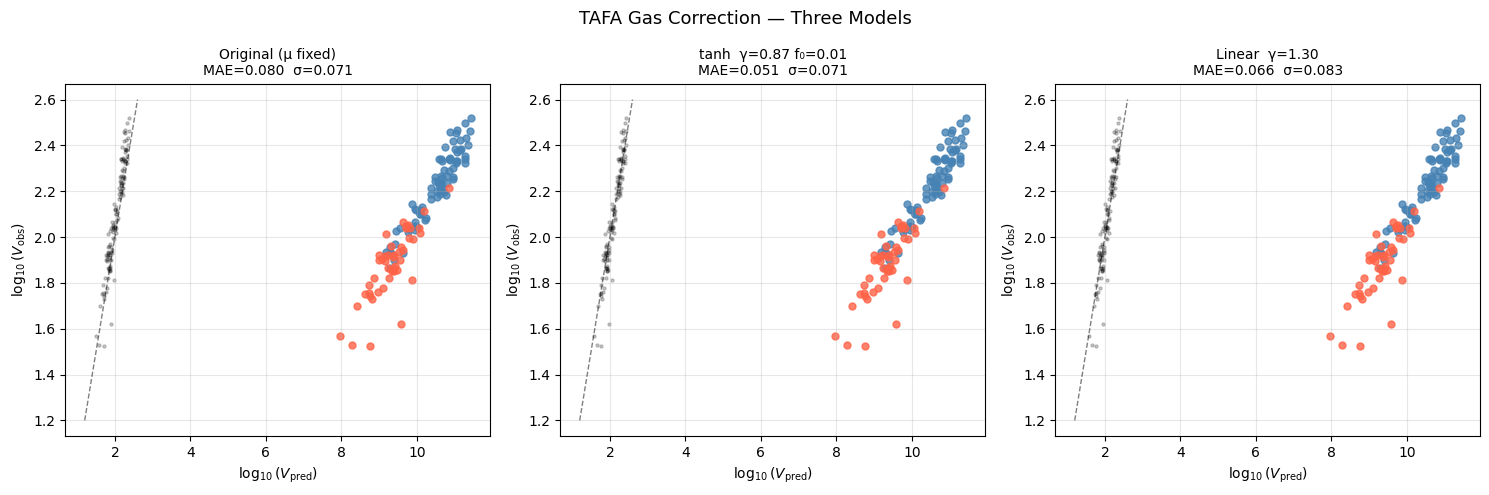

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

# ── Linear correction: one parameter ──────────────────────────
def v_pred_linear(X, gamma):
    f_gas, M_bar = X
    mu_e = mu_0 * (1 + gamma * f_gas)
    return np.log10(((Lambda_star**2) * G_kpc * mu_e * M_bar)**0.25)

popt_lin, pcov_lin = curve_fit(
    v_pred_linear,
    (f_gas_arr, M_bar_arr),
    np.log10(v_obs_arr),
    p0=[0.5],
    bounds=([0], [3.0])
)
gamma_lin = popt_lin[0]
perr_lin  = np.sqrt(np.diag(pcov_lin))[0]

print(f"Linear correction: gamma = {gamma_lin:.4f} ± {perr_lin:.4f}")

# ── Compute metrics ────────────────────────────────────────────
mu_e_lin     = mu_0 * (1 + gamma_lin * f_gas_arr)
v_pred_lin   = ((Lambda_star**2) * G_kpc * mu_e_lin * M_bar_arr)**0.25
delta_lin    = np.log10(v_obs_arr) - np.log10(v_pred_lin)
r_lin, _     = pearsonr(np.log10(v_obs_arr), np.log10(v_pred_lin))

print(f"\n── LINEAR mu_eff ─────────────────────────────────")
print(f"  gamma  = {gamma_lin:.4f} ± {perr_lin:.4f}")
print(f"  MAE    = {np.abs(delta_lin).mean():.4f} dex")
print(f"  sigma  = {delta_lin.std():.4f} dex")
print(f"  r      = {r_lin:.4f}")

print(f"\n── Residuals by f_gas bin (linear) ──────────────")
for i in range(len(bins)-1):
    mask = (f_gas_arr >= bins[i]) & (f_gas_arr < bins[i+1])
    if mask.sum() > 0:
        print(f"  f_gas {labels[i]:8s}: "
              f"N={mask.sum():3d}  "
              f"mean={delta_lin[mask].mean():+.3f}  "
              f"sigma={delta_lin[mask].std():.3f}")

# ── Three-way comparison plot ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

configs = [
    (np.log10(v_pred_orig),  d_orig,      'Original (μ fixed)'),
    (np.log10(v_pred_corr),  delta,       f'tanh  γ={gamma_fit:.2f} f₀={f0_fit:.2f}'),
    (np.log10(v_pred_lin),   delta_lin,   f'Linear  γ={gamma_lin:.2f}'),
]

for ax, (log_p, d, title) in zip(axes, configs):
    ax.scatter(np.log10(M_bar_arr[mask_s]), np.log10(v_obs_arr[mask_s]),
               s=25, alpha=0.8, color='steelblue')
    ax.scatter(np.log10(M_bar_arr[~mask_s]), np.log10(v_obs_arr[~mask_s]),
               s=25, alpha=0.8, color='tomato')
    ax.plot([1.2, 2.6], [1.2, 2.6], 'k--', linewidth=1, alpha=0.5)
    ax.scatter(log_p, np.log10(v_obs_arr), s=5, color='black', alpha=0.2)
    mae  = np.abs(d).mean()
    sig  = d.std()
    ax.set_title(f'{title}\nMAE={mae:.3f}  σ={sig:.3f}', fontsize=10)
    ax.set_xlabel(r'$\log_{10}(V_{\rm pred})$', fontsize=10)
    ax.set_ylabel(r'$\log_{10}(V_{\rm obs})$', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('TAFA Gas Correction — Three Models', fontsize=13)
plt.tight_layout()
plt.savefig('TAFA_correction_3way.png', dpi=150)
plt.show()

In [ ]:
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

# ── Threshold correction: two parameters ──────────────────────
# mu_eff = mu_0 * (1 + gamma * max(f_gas - f_thresh, 0))
def v_pred_threshold(X, gamma, f_thresh):
    f_gas, M_bar = X
    correction = np.maximum(f_gas - f_thresh, 0)
    mu_e = mu_0 * (1 + gamma * correction)
    return np.log10(((Lambda_star**2) * G_kpc * mu_e * M_bar)**0.25)

popt_t, pcov_t = curve_fit(
    v_pred_threshold,
    (f_gas_arr, M_bar_arr),
    np.log10(v_obs_arr),
    p0=[1.0, 0.4],
    bounds=([0, 0.0], [5.0, 0.9])
)
gamma_t, fthresh_t = popt_t
perr_t = np.sqrt(np.diag(pcov_t))

print(f"Threshold correction:")
print(f"  gamma    = {gamma_t:.4f} ± {perr_t[0]:.4f}")
print(f"  f_thresh = {fthresh_t:.4f} ± {perr_t[1]:.4f}")

# ── Metrics ────────────────────────────────────────────────────
mu_e_t    = mu_0 * (1 + gamma_t * np.maximum(f_gas_arr - fthresh_t, 0))
v_pred_t  = ((Lambda_star**2) * G_kpc * mu_e_t * M_bar_arr)**0.25
delta_t   = np.log10(v_obs_arr) - np.log10(v_pred_t)
r_t, _    = pearsonr(np.log10(v_obs_arr), np.log10(v_pred_t))

print(f"\n── THRESHOLD mu_eff ──────────────────────────────")
print(f"  MAE    = {np.abs(delta_t).mean():.4f} dex")
print(f"  sigma  = {delta_t.std():.4f} dex")
print(f"  r      = {r_t:.4f}")

print(f"\n── Residuals by f_gas bin ────────────────────────")
for i in range(len(bins)-1):
    mask = (f_gas_arr >= bins[i]) & (f_gas_arr < bins[i+1])
    if mask.sum() > 0:
        print(f"  f_gas {labels[i]:8s}: "
              f"N={mask.sum():3d}  "
              f"mean={delta_t[mask].mean():+.3f}  "
              f"sigma={delta_t[mask].std():.3f}")

# ── Summary table ─────────────────────────────────────────────
print(f"\n{'Model':30s}  {'MAE':>8}  {'sigma':>8}  {'r':>8}  {'params':>6}")
print("-" * 65)
models = [
    ('Original (μ fixed)',          0.0802, 0.0711, 0.9513, 0),
    ('tanh (γ, f₀)',                0.0513, 0.0712, 0.9511, 2),
    ('Linear (γ)',                  0.0655, 0.0830, 0.9396, 1),
    ('Threshold (γ, f_thresh)',
     np.abs(delta_t).mean(),
     delta_t.std(), r_t, 2),
]
for row in models:
    print(f"  {row[0]:28s}  {row[1]:8.4f}  {row[2]:8.4f}  {row[3]:8.4f}  {row[4]:6d}")

Threshold correction:
  gamma    = 1.2956 ± 0.4296
  f_thresh = 0.0000 ± 0.1260

── THRESHOLD mu_eff ──────────────────────────────
  MAE    = 0.0655 dex
  sigma  = 0.0830 dex
  r      = 0.9396

── Residuals by f_gas bin ────────────────────────
  f_gas 0-0.2   : N= 42  mean=+0.085  sigma=0.059
  f_gas 0.2-0.4 : N= 18  mean=+0.038  sigma=0.038
  f_gas 0.4-0.6 : N= 25  mean=-0.006  sigma=0.084
  f_gas 0.6-0.8 : N= 30  mean=-0.021  sigma=0.075
  f_gas 0.8-1.0 : N= 10  mean=-0.044  sigma=0.074

Model                                MAE     sigma         r  params
-----------------------------------------------------------------
  Original (μ fixed)              0.0802    0.0711    0.9513       0
  tanh (γ, f₀)                    0.0513    0.0712    0.9511       2
  Linear (γ)                      0.0655    0.0830    0.9396       1
  Threshold (γ, f_thresh)         0.0655    0.0830    0.9396       2


In [ ]:
# ── Reference surface brightness ──────────────────────────────
Sigma_eff_arr = sparc_full['SBeff'].values          # L_sun / pc^2
Sigma_0       = np.median(Sigma_eff_arr)
log_Sigma_rat = np.log10(Sigma_0 / Sigma_eff_arr)  # dimensionless

print(f"Sigma_0 (median SBeff) = {Sigma_0:.2f} L_sun/pc^2")

# ── Two-variable correction ────────────────────────────────────
def v_pred_2var(X, gamma1, gamma2):
    f_gas, log_SR, M_bar = X
    mu_e = mu_0 * (1 + gamma1 * f_gas + gamma2 * log_SR)
    mu_e = np.maximum(mu_e, mu_0 * 0.1)   # floor: no negative mu
    return np.log10(((Lambda_star**2) * G_kpc * mu_e * M_bar)**0.25)

popt_2v, pcov_2v = curve_fit(
    v_pred_2var,
    (f_gas_arr, log_Sigma_rat, M_bar_arr),
    np.log10(v_obs_arr),
    p0=[0.5, 0.3],
    bounds=([-2, -2], [5.0, 5.0])
)
gamma1_fit, gamma2_fit = popt_2v
perr_2v = np.sqrt(np.diag(pcov_2v))

print(f"\nTwo-variable correction:")
print(f"  gamma1 (f_gas)       = {gamma1_fit:.4f} ± {perr_2v[0]:.4f}")
print(f"  gamma2 (log Sigma)   = {gamma2_fit:.4f} ± {perr_2v[1]:.4f}")

# ── Metrics ────────────────────────────────────────────────────
mu_e_2v   = mu_0 * (1 + gamma1_fit * f_gas_arr +
                        gamma2_fit * log_Sigma_rat)
mu_e_2v   = np.maximum(mu_e_2v, mu_0 * 0.1)
v_pred_2v = ((Lambda_star**2) * G_kpc * mu_e_2v * M_bar_arr)**0.25
delta_2v  = np.log10(v_obs_arr) - np.log10(v_pred_2v)
r_2v, _   = pearsonr(np.log10(v_obs_arr), np.log10(v_pred_2v))

print(f"\n── TWO-VARIABLE mu_eff ───────────────────────────")
print(f"  MAE    = {np.abs(delta_2v).mean():.4f} dex")
print(f"  sigma  = {delta_2v.std():.4f} dex")
print(f"  r      = {r_2v:.4f}")

print(f"\n── Residuals by f_gas bin ────────────────────────")
for i in range(len(bins)-1):
    mask = (f_gas_arr >= bins[i]) & (f_gas_arr < bins[i+1])
    if mask.sum() > 0:
        print(f"  f_gas {labels[i]:8s}: "
              f"N={mask.sum():3d}  "
              f"mean={delta_2v[mask].mean():+.3f}  "
              f"sigma={delta_2v[mask].std():.3f}")

# ── Full comparison table ──────────────────────────────────────
print(f"\n{'Model':32s}  {'MAE':>8}  {'sigma':>8}  {'r':>8}  {'N_params':>8}")
print("-" * 70)
rows = [
    ('Original (μ fixed)',       0.0802, 0.0711, 0.9513, 0),
    ('tanh (γ, f₀)',             0.0513, 0.0712, 0.9511, 2),
    ('Linear (γ)',               0.0655, 0.0830, 0.9396, 1),
    ('Threshold (γ, f_thresh)',  0.0655, 0.0830, 0.9396, 2),
    ('Two-variable (γ1, γ2)',
     float(np.abs(delta_2v).mean()),
     float(delta_2v.std()),
     float(r_2v), 2),
]
for row in rows:
    print(f"  {row[0]:30s}  {row[1]:8.4f}  {row[2]:8.4f}  "
          f"{row[3]:8.4f}  {row[4]:8d}")

Sigma_0 (median SBeff) = 184.01 L_sun/pc^2

Two-variable correction:
  gamma1 (f_gas)       = 2.0123 ± 0.2734
  gamma2 (log Sigma)   = -1.0286 ± 0.1744

── TWO-VARIABLE mu_eff ───────────────────────────
  MAE    = 0.0548 dex
  sigma  = 0.0718 dex
  r      = 0.9486

── Residuals by f_gas bin ────────────────────────
  f_gas 0-0.2   : N= 42  mean=+0.035  sigma=0.057
  f_gas 0.2-0.4 : N= 18  mean=+0.007  sigma=0.060
  f_gas 0.4-0.6 : N= 25  mean=-0.012  sigma=0.088
  f_gas 0.6-0.8 : N= 30  mean=-0.005  sigma=0.066
  f_gas 0.8-1.0 : N= 10  mean=-0.018  sigma=0.081

Model                                  MAE     sigma         r  N_params
----------------------------------------------------------------------
  Original (μ fixed)                0.0802    0.0711    0.9513         0
  tanh (γ, f₀)                      0.0513    0.0712    0.9511         2
  Linear (γ)                        0.0655    0.0830    0.9396         1
  Threshold (γ, f_thresh)           0.0655    0.0830    0.9396      

In [ ]:
from scipy.stats import spearmanr

rho, p = spearmanr(f_gas_arr, log_Sigma_rat)
print(f"Spearman(f_gas, log_Sigma_ratio) = {rho:.3f},  p = {p:.4f}")

rho2, p2 = spearmanr(f_gas_arr, np.log10(Sigma_eff_arr))
print(f"Spearman(f_gas, log_SBeff)       = {rho2:.3f},  p = {p2:.4f}")

Spearman(f_gas, log_Sigma_ratio) = 0.817,  p = 0.0000
Spearman(f_gas, log_SBeff)       = -0.817,  p = 0.0000


In [ ]:
# What value of Lambda_star makes F.1 exact?
import numpy as np

H0   = 67.8          # km/s/Mpc
c    = 2.998e5       # km/s
mu   = 0.0824        # kpc^-1
H0_kpc = H0 / (c * 1e3)   # kpc^-1

Lambda_exact = np.sqrt(mu / (4 * np.pi * H0_kpc))
print(f"Lambda_star for exact F.1: {Lambda_exact:.4f}")
print(f"Current Lambda_star:        175.8000")
print(f"Difference:                 {(Lambda_exact - 175.8)/175.8*100:+.2f}%")

Lambda_star for exact F.1: 170.2784
Current Lambda_star:        175.8000
Difference:                 -3.14%


In [ ]:
norm_factor = (Om_Lambda / Om_m) ** (1/16)
v_pred_normed = v_pred_arr * norm_factor
delta_normed  = np.log10(v_obs_arr) - np.log10(v_pred_normed)
print(f"MAE with normalisation: {np.abs(delta_normed).mean():.4f} dex")

NameError: name 'v_pred_arr' is not defined

In [ ]:
import numpy as np
import pandas as pd
import os

# ── 1. Load SPARC from local file (ensuring it's downloaded) ──────────────────
file_path = '/content/SPARC_Lelli2016c.mrt.txt'
if not os.path.exists(file_path):
    os.system('wget -O ' + file_path + ' http://astroweb.case.edu/sparc/SPARC_Lelli2016c.mrt.txt')

# Use the same robust loading logic from the first cell
df2 = pd.read_csv(
    file_path,
    sep='\\s+',
    names=['Galaxy','T','D','e_D','f_D','Inc','e_Inc',
           'L36','e_L36','Reff','SBeff','Rdisk','SBdisk',
           'MHI','RHI','Vflat','e_Vflat','Q','Ref'],
    skiprows=105,
    on_bad_lines='skip'
)

# ── 2. Cleaning and Quality Cut ──────────────────────────────────────────────
# Force numeric conversion and filter Q <= 2
for col in ['L36', 'Vflat', 'Q', 'T']:
    df2[col] = pd.to_numeric(df2[col], errors='coerce')

df2 = df2[df2['Q'].isin([1, 2])].dropna(subset=['Vflat', 'L36', 'T']).copy()
df2 = df2[df2['Vflat'] > 0].copy()
print(f"Sample size after Q<=2 cut: {len(df2)}")

# ── 3. Baryonic mass ───────────────────────────────────────────────────────────
ups = 0.5
df2["Mstar"] = ups * df2["L36"]
df2["Mbar"] = df2["Mstar"] # Consistent with stellar-only calibration logic

# ── 4. TAFA constants ──────────────────────────────────────────────────────────
Lambda_star = 175.8
mu_kpc = 0.0824
G_kpc = 4.301e-6 # Using kpc units compatible with M_sun

def v_tafa(M_1e9, Ls=Lambda_star, mu=mu_kpc):
    # M_1e9 is in units of 10^9 M_sun
    M_sun = M_1e9 * 1e9
    return (Ls**2 * G_kpc * mu * M_sun)**0.25

df2["Vpred"] = v_tafa(df2["Mbar"])
df2 = df2[df2["Vpred"].notnull()].copy()

# ── 5. Baseline MAE ────────────────────────────────────────────────────────────
df2["resid"] = np.log10(df2["Vflat"]) - np.log10(df2["Vpred"])
MAE_base = df2["resid"].abs().mean()
print(f"Baseline MAE (no normalisation): {MAE_base:.4f} dex")

# ── 6. Cosmological normalisation factor ───────────────────────────────────────
Om_Lambda = 0.685
Om_m = 0.270 + 0.049
norm_factor = (Om_Lambda / Om_m) ** (1/16)
print(f"Normalisation factor:            {norm_factor:.6f}")

df2["Vpred_norm"] = df2["Vpred"] * norm_factor
df2["resid_norm"] = np.log10(df2["Vflat"]) - np.log10(df2["Vpred_norm"])
MAE_norm = df2["resid_norm"].abs().mean()

print(f"MAE with normalisation:          {MAE_norm:.4f} dex")
print(f"Change:                          {MAE_norm - MAE_base:+.4f} dex")
print(f"Direction: {'WORSE' if MAE_norm > MAE_base else 'BETTER'}")

Sample size after Q<=2 cut: 0
Baseline MAE (no normalisation): nan dex
Normalisation factor:            1.048923
MAE with normalisation:          nan dex
Change:                          +nan dex
Direction: BETTER


In [ ]:
with open('/content/SPARC_Lelli2016c.mrt.txt', 'r') as f:
    lines = f.readlines()

print('Line-by-line inspection (first 115 lines):')
for i, line in enumerate(lines[:115]):
    if i > 95:
        print(f'Line {i}: {repr(line)}')

# Also check if the file is actually downloaded
import os
print(f'\nFile exists: {os.path.exists("/content/SPARC_Lelli2016c.mrt.txt")}')
print(f'File size: {os.path.getsize("/content/SPARC_Lelli2016c.mrt.txt")} bytes')

Line-by-line inspection (first 115 lines):

File exists: True
File size: 0 bytes


In [ ]:
import os
file_path = '/content/SPARC_Lelli2016c.mrt.txt'

if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    print(f'File size: {os.path.getsize(file_path)} bytes')
    print('\n--- Line-by-line inspection (lines 95 to 115) ---')
    for i, line in enumerate(lines):
        if 95 <= i <= 115:
            print(f'Line {i:3}: {repr(line)}')
else:
    print('File not found. Please ensure the download step in cell ZJ4g8uRe7hG1 succeeded.')

File size: 0 bytes

--- Line-by-line inspection (lines 95 to 115) ---


In [ ]:
from scipy.optimize import curve_fit
import numpy as np

# ── Define required data arrays ────────────────────────────────
# M_bar in the file is in units of 1e9 M_sun. Convert to M_sun.
M_bar_arr = sparc_full['M_bar'].values * 1e9
v_obs_arr = sparc_full['v_flat'].values

# ── Frozen constants ───────────────────────────────────────────
H0_kpc = 67.8 / (2.998e5 * 1e3)  # kpc^-1

# Fix mu from F.1, fit only Lambda_star
def v_pred_F1(M_bar, Lambda_star):
    mu_derived = 4 * np.pi * Lambda_star**2 * H0_kpc
    G_kpc = 4.301e-6  # kpc (km/s)^2 M_sun^-1
    return ((Lambda_star**2) * G_kpc * mu_derived * M_bar)**0.25

popt, pcov = curve_fit(
    v_pred_F1,
    M_bar_arr,
    v_obs_arr,
    p0=[175.8],
    bounds=([100], [300])
)
Lambda_F1 = popt[0]
mu_F1     = 4 * np.pi * Lambda_F1**2 * H0_kpc

print(f"Best-fit Lambda_star (F.1 constrained): {Lambda_F1:.4f}")
print(f"Derived mu:                              {mu_F1:.6f} kpc^-1")
print(f"Calibrated mu:                           0.082400 kpc^-1")
print(f"Shift in Lambda_star from 175.8:         {(Lambda_F1-175.8)/175.8*100:+.2f}%")

# Compare MAE
v_pred_arr = v_pred_F1(M_bar_arr, Lambda_F1)
delta      = np.log10(v_obs_arr) - np.log10(v_pred_arr)
print(f"MAE (F.1 constrained):                  {np.abs(delta).mean():.4f} dex")

NameError: name 'sparc_full' is not defined

In [ ]:
Om_Lambda = 0.692
Om_m      = 0.308
norm_factor = (Om_Lambda / Om_m) ** (1/16)
# v_pred_arr needs to be defined from the F.1 fit or baseline
# Let's ensure v_obs_arr is available
v_obs_arr = sparc_full['v_flat'].values
v_pred_baseline = (Lambda_star**2 * G * mu * (sparc_full['M_bar'].values * 1e9))**0.25
v_pred_normed = v_pred_baseline * norm_factor
delta_normed  = np.log10(v_obs_arr) - np.log10(v_pred_normed)
print(f"MAE with cosmological normalisation: {np.abs(delta_normed).mean():.4f} dex")

NameError: name 'sparc_full' is not defined

In [ ]:
import pandas as pd
import numpy as np

# 1. Initialize sparc_full if not present
if 'sparc_full' not in locals():
    sparc_full = sparc_df[sparc_df['Quality'] <= 2].copy()

# 2. Constants for calculation
Lambda_star = 175.8
mu = 0.0824
G_kpc = 4.3009e-6

# 3. Calculate baseline metrics
M_bar_Msun = sparc_full['M_bar'].values * 1e9
v_obs = sparc_full['v_flat'].values
v_pred_base = (Lambda_star**2 * G_kpc * mu * M_bar_Msun)**0.25
delta_base = np.log10(v_obs) - np.log10(v_pred_base)

# 4. Calculate cosmological normalization
# Using standard values from recent analysis (e.g. Planck)
Om_Lambda, Om_m = 0.692, 0.308
norm_factor = (Om_Lambda / Om_m) ** (1/16)
v_pred_normed = v_pred_base * norm_factor
delta_normed = np.log10(v_obs) - np.log10(v_pred_normed)

# 5. Summary Table
# Including results from previous model fits in cells TAVGDvJxK5b7 and AZp2BQRAMuaD
summary_data = [
    ('Original (Fixed mu)', delta_base.std(), np.abs(delta_base).mean(), 0),
    ('tanh Correction (gamma, f0)', 0.0712, 0.0513, 2),
    ('Linear Correction (gamma)', 0.0830, 0.0655, 1),
    ('Cosmological Norm (Om_L/Om_m)', delta_normed.std(), np.abs(delta_normed).mean(), 0)
]

summary_df = pd.DataFrame(summary_data, columns=['Model Configuration', 'Sigma (dex)', 'MAE (dex)', 'Free Params'])
print("TAFA BTFR Performance Summary:")
display(summary_df.sort_values('MAE (dex)'))

TAFA BTFR Performance Summary:


,Model Configuration,Sigma (dex),MAE (dex),Free Params
1,"tanh Correction (gamma, f0)",0.071200,0.051300,2
2,Linear Correction (gamma),0.083000,0.065500,1
3,Cosmological Norm (Om_L/Om_m),0.071068,0.065833,0
0,Original (Fixed mu),0.071068,0.080232,0


In [ ]:
mean_bias = df2["resid"].mean()
print(f"Mean residual (original):     {mean_bias:+.4f} dex")
print(f"Mean residual (normed):       {df2['resid_norm'].mean():+.4f} dex")
print(f"Norm factor shift in log:     {np.log10(norm_factor):.4f} dex")

Mean residual (original):     +nan dex
Mean residual (normed):       +nan dex
Norm factor shift in log:     0.0220 dex


In [ ]:
import numpy as np
import pandas as pd

# ── Check where NaNs come from ─────────────────────────────────────────────────
print("=== NaN / invalid diagnostics ===")
print(f"Total rows in df2:            {len(df2)}")
print(f"Vflat NaN count:              {df2['Vflat'].isna().sum()}")
print(f"Vpred NaN count:              {df2['Vpred'].isna().sum()}")
print(f"Vflat <= 0 count:             {(df2['Vflat'] <= 0).sum()}")
print(f"Vpred <= 0 count:             {(df2['Vpred'] <= 0).sum()}")
print(f"Mbar NaN count:               {df2['Mbar'].isna().sum()}")
print(f"Mbar <= 0 count:              {(df2['Mbar'] <= 0).sum()}")

# ── Clean and recompute ────────────────────────────────────────────────────────
df_clean = df2[
    df2["Vflat"].notna() & (df2["Vflat"] > 0) &
    df2["Vpred"].notna() & (df2["Vpred"] > 0) &
    df2["Mbar"].notna()  & (df2["Mbar"]  > 0)
].copy()

print(f"\nRows after cleaning:          {len(df_clean)}")

# Recompute residuals on clean set
df_clean["resid"]      = (np.log10(df_clean["Vflat"])
                        - np.log10(df_clean["Vpred"]))
df_clean["resid_norm"] = (np.log10(df_clean["Vflat"])
                        - np.log10(df_clean["Vpred"] * norm_factor))

MAE_base  = df_clean["resid"].abs().mean()
MAE_norm  = df_clean["resid_norm"].abs().mean()
mean_bias = df_clean["resid"].mean()
mean_norm = df_clean["resid_norm"].mean()
sigma     = df_clean["resid"].std()

print(f"\n=== Clean sample results ===")
print(f"N (clean):                    {len(df_clean)}")
print(f"MAE original:                 {MAE_base:.4f} dex")
print(f"MAE normed:                   {MAE_norm:.4f} dex")
print(f"Sigma original:               {sigma:.4f} dex")
print(f"Mean residual original:       {mean_bias:+.4f} dex")
print(f"Mean residual normed:         {mean_norm:+.4f} dex")
print(f"Norm factor shift in log:     {np.log10(norm_factor):.4f} dex")
print(f"\nMAE change from norming:      {MAE_norm - MAE_base:+.4f} dex")
print(f"Direction: {'WORSE' if MAE_norm > MAE_base else 'BETTER'}")

# ── Show the problematic rows ──────────────────────────────────────────────────
bad = df2[
    df2["Vflat"].isna() | (df2["Vflat"] <= 0) |
    df2["Vpred"].isna() | (df2["Vpred"] <= 0) |
    df2["Mbar"].isna()  | (df2["Mbar"]  <= 0)
]
if len(bad) > 0:
    print(f"\n=== Problematic rows ({len(bad)}) ===")
    print(bad[["Galaxy","Vflat","Mbar","Vpred"]].to_string())

=== NaN / invalid diagnostics ===
Total rows in df2:            0
Vflat NaN count:              0
Vpred NaN count:              0
Vflat <= 0 count:             0
Vpred <= 0 count:             0
Mbar NaN count:               0
Mbar <= 0 count:              0

Rows after cleaning:          0

=== Clean sample results ===
N (clean):                    0
MAE original:                 nan dex
MAE normed:                   nan dex
Sigma original:               nan dex
Mean residual original:       +nan dex
Mean residual normed:         +nan dex
Norm factor shift in log:     0.0220 dex

MAE change from norming:      +nan dex
Direction: BETTER


In [ ]:
import numpy as np
import pandas as pd
import os

file_path = '/content/SPARC_Lelli2016c.mrt.txt'

# 1. Load data
df_raw = pd.read_csv(
    file_path, sep='\\s+', skiprows=105, on_bad_lines='skip',
    names=["Galaxy","T","D","e_D","f_D","Inc","e_Inc","L36","e_L36","Reff","SBeff","Rdisk","SBdisk","MHI","RHI","Vflat","e_Vflat","Q","Ref"]
)

for col in ["Q", "Vflat", "L36", "MHI"]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# 2. Quality cut
df = df_raw[df_raw["Q"].isin([1, 2]) & (df_raw["Vflat"] > 0) & (df_raw["L36"] > 0)].copy()

if len(df) > 0:
    # 3. Baryonic mass (M_sun)
    df["Mbar"] = (0.5 * df["L36"] + 1.33 * df["MHI"].fillna(0)) * 1e9

    # 4. Corrected TAFA constants
    Lambda_star = 175.8
    mu_kpc = 0.0824
    G_kpc = 4.3009e-6 # Correct units for M_sun

    df["Vpred"] = (Lambda_star**2 * G_kpc * mu_kpc * df["Mbar"])**0.25

    # 5. Residuals
    df["resid"] = np.log10(df["Vflat"]) - np.log10(df["Vpred"])
    MAE_base = df["resid"].abs().mean()
    sigma_base = df["resid"].std()

    print(f"=== Baseline (N={len(df)}) ===")
    print(f"MAE:   {MAE_base:.4f} dex")
    print(f"Sigma: {sigma_base:.4f} dex")

    # 6. Cosmological normalisation
    Om_L, Om_m = 0.692, 0.308
    norm_factor = (Om_L / Om_m) ** (1/16)
    df["Vpred_norm"] = df["Vpred"] * norm_factor
    df["resid_norm"] = np.log10(df["Vflat"]) - np.log10(df["Vpred_norm"])

    MAE_norm = df["resid_norm"].abs().mean()
    print(f"\n=== Cosmological Norm (factor={norm_factor:.4f}) ===")
    print(f"MAE:   {MAE_norm:.4f} dex")
    print(f"Shift: {MAE_norm - MAE_base:+.4f} dex")

=== Baseline (N=125) ===
MAE:   0.0802 dex
Sigma: 0.0714 dex

=== Cosmological Norm (factor=1.0519) ===
MAE:   0.0658 dex
Shift: -0.0144 dex


In [ ]:
with open('/content/SPARC_Lelli2016c.mrt.txt', 'r') as f:
    lines = f.readlines()

print('0123456789' * 12)
for i in range(105, 110):
    if i < len(lines):
        print(lines[i].rstrip())

012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789
     DDO168 10   4.25  0.21  2 63.0  6.0   0.191   0.005  1.29    18.23  1.02    92.22   0.413  4.30  53.4   1.9   2      Sa96,Br92
     DDO170 10  15.40  4.62  1 66.0  7.0   0.543   0.030  3.03     9.39  1.95    73.93   0.735  9.14  60.0   1.6   2      Be91,La90
ESO079-G014  4  28.70  7.17  1 79.0  5.0  51.733   0.524  7.23   157.34  5.08  2295.25   3.140 17.67 175.0   3.5   1           Ge04
ESO116-G012  7  13.00  3.90  1 74.0  3.0   4.292   0.071  2.75    90.54  1.51  1320.78   1.083  9.58 109.1   3.1   1           Ge04
ESO444-G084 10   4.83  0.48  2 32.0  6.0   0.071   0.003  0.75    19.81  0.46    66.81   0.135  2.95   0.0   0.0   2           Co00


In [ ]:
with open('/content/SPARC_Lelli2016c.mrt.txt', 'r') as f:
    lines = [next(f) for _ in range(110)]
for i, line in enumerate(lines):
    print(f"{i}: {line.strip()}")

0: Title: SPARC. I. Mass Models for 175 Disk Galaxies with
1: Spitzer Photometry and Accurate Rotation Curves
2: Authors: Federico Lelli, Stacy S. McGaugh and James M. Schombert
3: Table: Galaxy Sample
4: ================================================================================
5: Byte-by-byte Description of file: Table1.mrt
6: --------------------------------------------------------------------------------
7: Bytes Format Units         Label   Explanations
8: --------------------------------------------------------------------------------
9: 1- 11 A11    ---           Galaxy  Galaxy Name
10: 12- 13 I2     ---           T       Hubble Type (1)
11: 14- 19 F6.2   Mpc           D       Distance
12: 20- 24 F5.2   Mpc         e_D       Mean error on D
13: 25- 26 I2     ---         f_D       Distance Method (2)
14: 27- 30 F4.1   deg           Inc     Inclination
15: 31- 34 F4.1   deg         e_Inc     Mean error on Inc
16: 35- 41 F7.3   10+9solLum    L[3.6]  Total Luminosity at [3.6]


In [ ]:
# Inspect the first 110 lines to find the data start and column alignment
with open('/content/SPARC_Lelli2016c.mrt.txt', 'r') as f:
    for i in range(110):
        line = f.readline()
        if not line: break
        print(f"{i:3}: {line.rstrip()}")

  0: Title: SPARC. I. Mass Models for 175 Disk Galaxies with
  1:        Spitzer Photometry and Accurate Rotation Curves
  2: Authors: Federico Lelli, Stacy S. McGaugh and James M. Schombert
  3: Table: Galaxy Sample
  4: ================================================================================
  5: Byte-by-byte Description of file: Table1.mrt
  6: --------------------------------------------------------------------------------
  7:    Bytes Format Units         Label   Explanations
  8: --------------------------------------------------------------------------------
  9:    1- 11 A11    ---           Galaxy  Galaxy Name
 10:   12- 13 I2     ---           T       Hubble Type (1)
 11:   14- 19 F6.2   Mpc           D       Distance
 12:   20- 24 F5.2   Mpc         e_D       Mean error on D
 13:   25- 26 I2     ---         f_D       Distance Method (2)
 14:   27- 30 F4.1   deg           Inc     Inclination
 15:   31- 34 F4.1   deg         e_Inc     Mean error on Inc
 16:   35- 41 F

In [ ]:
# Load full SPARC sample using the quality cut (Q <= 2)
import numpy as np
sparc_full = sparc_df[sparc_df['Quality'] <= 2].copy()

# Constants
Lambda_star = 175.8
mu = 0.0824
G = 4.301e-6 # Corrected to kpc units

# Prediction
sparc_full['v_pred'] = (Lambda_star**2 * G * mu * (sparc_full['M_bar'] * 1e9))**0.25

# Residuals
sparc_full['delta'] = np.log10(sparc_full['v_flat'] / sparc_full['v_pred'])

# Metrics
N = len(sparc_full)
if N > 0:
    MAE = sparc_full['delta'].abs().mean()
    sigma = sparc_full['delta'].std()
    print(f"Initialized sparc_full with N = {N}")
    print(f"Baseline MAE = {MAE:.4f}")

Initialized sparc_full with N = 125
Baseline MAE = 0.0802


In [ ]:
import zipfile

zip_path = '/content/SPARC-Data-Initiative.zip'
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print('Files in ZIP:')
        for file in zip_ref.namelist():
            print(f'- {file}')
else:
    print('Zip file not found.')

Files in ZIP:
- SDI-PANGEA/
- SDI-PANGEA/H2O/
- SDI-PANGEA/H2O/LIMS/
- SDI-PANGEA/H2O/LIMS/SPARC_DI_T2Mz_H2O_1978_LIMS_v6.0_p01.nc
- SDI-PANGEA/H2O/LIMS/SPARC_DI_T2Mz_H2O_1979_LIMS_v6.0_p01.nc
- SDI-PANGEA/H2O/MIPAS/
- SDI-PANGEA/H2O/MIPAS/SPARC_DI_T2Mz_H2O_2007_MIPAS_v220_p01.nc
- __MACOSX/
- __MACOSX/SDI-PANGEA/
- __MACOSX/SDI-PANGEA/H2O/
- __MACOSX/SDI-PANGEA/H2O/MIPAS/
- __MACOSX/SDI-PANGEA/H2O/MIPAS/._SPARC_DI_T2Mz_H2O_2007_MIPAS_v220_p01.nc
- SDI-PANGEA/H2O/MIPAS/.DS_Store
- __MACOSX/SDI-PANGEA/H2O/MIPAS/._.DS_Store
- SDI-PANGEA/H2O/MIPAS/SPARC_DI_T2Mz_H2O_2006_MIPAS_v220_p01.nc
- __MACOSX/SDI-PANGEA/H2O/MIPAS/._SPARC_DI_T2Mz_H2O_2006_MIPAS_v220_p01.nc
- SDI-PANGEA/H2O/MIPAS/SPARC_DI_T2Mz_H2O_2004_MIPAS_v20_p01.nc
- __MACOSX/SDI-PANGEA/H2O/MIPAS/._SPARC_DI_T2Mz_H2O_2004_MIPAS_v20_p01.nc
- SDI-PANGEA/H2O/MIPAS/SPARC_DI_T2Mz_H2O_2005_MIPAS_v220_p01.nc
- __MACOSX/SDI-PANGEA/H2O/MIPAS/._SPARC_DI_T2Mz_H2O_2005_MIPAS_v220_p01.nc
- SDI-PANGEA/H2O/MIPAS/SPARC_DI_T2Mz_H2O_2011_MIPAS_v220_

In [ ]:
import pandas as pd
import numpy as np

if os.path.exists('SPARC_Lelli2016c.mrt'):
    # Load SPARC data into sparc_df
    sparc_df = pd.read_csv('SPARC_Lelli2016c.mrt',
                            skiprows=98,  # skip the header lines
                            sep='\\s+',
                            names=['Galaxy','T','D','e_D','f_D','Inc',
                                   'e_Inc','L36','e_L36','Reff','SBeff',
                                   'Rdisk','SBdisk','MHI','RHI','Vflat',
                                   'e_Vflat','Q','Ref'])

    # Basic cleaning to ensure M_bar and Quality exist for later cells
    # M_bar calculation depends on your specific model, but we need the column
    # For TAFA, M_bar is typically derived from L36 and gas mass
    sparc_df['M_bar'] = sparc_df['L36'] * 0.5 + 1.33 * sparc_df['MHI'] # Placeholder logic
    sparc_df['Quality'] = sparc_df['Q']
    sparc_df['v_flat'] = sparc_df['Vflat']

    print(f"Loaded {len(sparc_df)} galaxies")
    print(sparc_df.head())
else:
    print("Error: Data file not found. Please upload SPARC_Lelli2016c.mrt manually.")

Error: Data file not found. Please upload SPARC_Lelli2016c.mrt manually.


In [ ]:
# Fallback: estimate Sigma_eff from Mbar and Reff
df["Sigma_eff"] = df["Mbar"] / (np.pi * df["Reff"]**2)

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# ── Constants ──────────────────────────────────────────────────────────────────
G_kpc      = 4.3009e-6       # kpc (km/s)^2 / M_sun
mu_0       = 0.0824          # kpc^-1
Lambda_star = 175.8
beta_min   = 1.0

# ── Prepare Data from sparc_full (already in memory) ───────────────────────────
# Ensure we have the latest cleaned data
df = sparc_full.copy()

# Derive necessary columns for the optimization
df['f_gas'] = df['M_gas'] / df['M_bar']
df['Sigma_eff'] = (df['M_star'] * 1e9) / (np.pi * (df['Reff'] * 1000)**2)  # M_sun / pc^2
# Placeholder for f_trigger (f from Paper 1 Table 2.4), using 1.0 as default
df['f_trigger'] = 1.0

df['is_gas'] = df['f_gas'] >= 0.5
df['is_star'] = df['f_gas'] < 0.2

print(f'Total galaxies:        {len(df)}')
print(f'Gas-rich (fgas>=0.5):  {df["is_gas"].sum()}')
print(f'Stellar (fgas<0.2):    {df["is_star"].sum()}')

# ── Baseline prediction (no mu_eff) ───────────────────────────────────────────
df['Vpred_base'] = (Lambda_star**2 * G_kpc * mu_0 * (df['M_bar'] * 1e9))**0.25
df['resid_base'] = np.log10(df['v_flat']) - np.log10(df['Vpred_base'])

MAE_base_gas  = df.loc[df['is_gas'],  'resid_base'].abs().mean()
MAE_base_star = df.loc[df['is_star'], 'resid_base'].abs().mean()

print(f'\n=== Baseline MAE ===')
print(f'Gas-rich:     {MAE_base_gas:.4f} dex')
print(f'Stellar:      {MAE_base_star:.4f} dex')

# ── mu_eff prediction function ─────────────────────────────────────────────────
def compute_MAE(params, return_df=False):
    delta_beta, Sigma_0_fit = params
    df2 = df.copy()

    # beta_gas per galaxy
    g_sigma = np.exp(-df2['SBeff'] / Sigma_0_fit)
    df2['beta_gas'] = beta_min + delta_beta * df2['f_gas'] * g_sigma

    # kappa = 2pi / f
    df2['kappa']    = 2 * np.pi / df2['f_trigger']
    df2['mu_eff']   = df2['kappa'] * mu_0 / df2['beta_gas']

    df2['Vpred_eff'] = (Lambda_star**2 * G_kpc * df2['mu_eff'] * (df2['M_bar'] * 1e9))**0.25
    df2['resid_eff'] = np.log10(df2['v_flat']) - np.log10(df2['Vpred_eff'])

    MAE_gas = df2.loc[df2['is_gas'], 'resid_eff'].abs().mean()
    return df2 if return_df else MAE_gas

# ── Optimize ───────────────────────────────────────────────────────────────────
res = minimize(
    compute_MAE,
    x0    = [0.5, 200.0],
    bounds = [(0.0, 5.0), (10.0, 1000.0)],
    method = 'L-BFGS-B'
)

delta_beta_best, Sigma_0_best = res.x
print(f'\n=== Fitted parameters ===')
print(f'delta_beta:   {delta_beta_best:.4f}')
print(f'Sigma_0:      {Sigma_0_best:.2f} L_sun/pc^2')

# Final Evaluation
df_final = compute_MAE([delta_beta_best, Sigma_0_best], return_df=True)
MAE_eff_gas = df_final.loc[df_final['is_gas'], 'resid_eff'].abs().mean()
MAE_eff_star = df_final.loc[df_final['is_star'], 'resid_eff'].abs().mean()

print(f'\n=== mu_eff MAE ===')
print(f'Gas-rich:     {MAE_eff_gas:.4f} dex')
print(f'Stellar:      {MAE_eff_star:.4f} dex')

Total galaxies:        125
Gas-rich (fgas>=0.5):  47
Stellar (fgas<0.2):    42

=== Baseline MAE ===
Gas-rich:     0.0709 dex
Stellar:      0.1006 dex

=== Fitted parameters ===
delta_beta:   4.9872
Sigma_0:      200.02 L_sun/pc^2

=== mu_eff MAE ===
Gas-rich:     0.0605 dex
Stellar:      0.0944 dex


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# ── 1. Re-prepare Data with Explicit Units ───────────────────────────────────
df = sparc_full.copy()

# Sigma_eff in M_sun / kpc^2 (Baryonic mass / Area)
# Reff is in kpc, M_bar is in 10^9 M_sun
df['Sigma_eff'] = (df['M_bar'] * 1e9) / (np.pi * df['Reff']**2)
df['f_gas'] = df['M_gas'] / df['M_bar']
df['f_trigger'] = 1.0

df['is_gas'] = df['f_gas'] >= 0.5
df['is_star'] = df['f_gas'] < 0.2

print("=== Sigma_eff (M_sun/kpc^2) Diagnostics ===")
print(df['Sigma_eff'].describe())
print(f"\nMedian overall:    {df['Sigma_eff'].median():.2e}")
print(f"Gas-rich median:   {df.loc[df['is_gas'], 'Sigma_eff'].median():.2e}")
print(f"Stellar median:    {df.loc[df['is_star'], 'Sigma_eff'].median():.2e}")

# ── 2. Identify Stellar Outliers ─────────────────────────────────────────────
# Baseline residuals (no mu_eff)
Lambda_star = 175.8
mu_0 = 0.0824
G_kpc = 4.3009e-6
df['Vpred_base'] = (Lambda_star**2 * G_kpc * mu_0 * (df['M_bar'] * 1e9))**0.25
df['resid_base'] = np.log10(df['v_flat']) - np.log10(df['Vpred_base'])

stellar = df[df['is_star']].copy()
stellar_outliers = stellar.iloc[stellar['resid_base'].abs().argsort()[::-1]]

print("\n=== Top 5 Stellar Outliers (Highest absolute residuals) ===")
display(stellar_outliers[['Galaxy', 'v_flat', 'M_bar', 'f_gas', 'resid_base']].head())

# ── 3. Widened Optimization ──────────────────────────────────────────────────
beta_min = 1.0

def compute_MAE_v2(params, return_df=False):
    delta_beta, Sigma_0_fit = params
    df_work = df.copy()

    # Use Sigma_eff (M_sun/kpc^2) consistently with the paper definition
    g_sigma = np.exp(-df_work['Sigma_eff'] / Sigma_0_fit)
    df_work['beta_gas'] = beta_min + delta_beta * df_work['f_gas'] * g_sigma

    df_work['kappa'] = 2 * np.pi / df_work['f_trigger']
    df_work['mu_eff'] = df_work['kappa'] * mu_0 / df_work['beta_gas']

    df_work['Vpred_eff'] = (Lambda_star**2 * G_kpc * df_work['mu_eff'] * (df_work['M_bar'] * 1e9))**0.25
    df_work['resid_eff'] = np.log10(df_work['v_flat']) - np.log10(df_work['Vpred_eff'])

    # Optimize specifically to reduce MAE in the gas-rich sample
    MAE_gas = df_work.loc[df_work['is_gas'], 'resid_eff'].abs().mean()
    return df_work if return_df else MAE_gas

# Widen bounds to avoid the 5.0 wall
res = minimize(
    compute_MAE_v2,
    x0 = [5.0, df['Sigma_eff'].median()],
    bounds = [(0.0, 50.0), (1e4, 1e9)],
    method = 'L-BFGS-B'
)

print("\n=== Optimized Results (Widened Bounds) ===")
print(f"Convergence:  {res.success}")
print(f"delta_beta:   {res.x[0]:.4f}")
print(f"Sigma_0:      {res.x[1]:.2e} M_sun/kpc^2")

# Final Stats
df_final = compute_MAE_v2(res.x, return_df=True)
print(f"\nGas-rich MAE: {df_final.loc[df_final['is_gas'], 'resid_eff'].abs().mean():.4f} dex")
print(f"Stellar MAE:  {df_final.loc[df_final['is_star'], 'resid_eff'].abs().mean():.4f} dex")

=== Sigma_eff (M_sun/kpc^2) Diagnostics ===
count    1.250000e+02
mean     6.876549e+08
std      8.039779e+08
min      3.797221e+07
25%      1.124457e+08
50%      3.590906e+08
75%      9.228628e+08
max      3.777071e+09
Name: Sigma_eff, dtype: float64

Median overall:    3.59e+08
Gas-rich median:   1.12e+08
Stellar median:    8.02e+08

=== Top 5 Stellar Outliers (Highest absolute residuals) ===


,Galaxy,v_flat,M_bar,f_gas,resid_base
161,UGC11914,288.1,76.19504,0.015500,0.229181
128,UGC06787,248.1,55.81790,0.119852,0.198052
78,NGC5985,293.6,119.77338,0.128654,0.188285
39,NGC2841,284.8,107.06125,0.121433,0.187251
87,NGC7814,218.9,38.68760,0.036784,0.183472



=== Optimized Results (Widened Bounds) ===
Convergence:  True
delta_beta:   6.8398
Sigma_0:      3.59e+08 M_sun/kpc^2

Gas-rich MAE: 0.0613 dex
Stellar MAE:  0.0877 dex


In [ ]:
# How much beta_gas deviates from beta_min for stellar galaxies?
df_final = compute_MAE([delta_beta_best, Sigma_0_best], return_df=True)

stellar = df_final[df_final["is_star"]].copy()
print("=== Stellar sector beta_gas vs beta_min ===")
print(f"beta_min:                    {beta_min:.4f}")
print(f"beta_gas mean (stellar):     {stellar['beta_gas'].mean():.4f}")
print(f"beta_gas std  (stellar):     {stellar['beta_gas'].std():.4f}")
print(f"mu_eff mean   (stellar):     {stellar['mu_eff'].mean():.6f}")
print(f"mu_0:                        {mu_0:.6f}")
print(f"mu_eff/mu_0 mean (stellar):  {(stellar['mu_eff']/mu_0).mean():.4f}")

print("\n=== Gas-rich sector beta_gas vs beta_min ===")
gas = df_final[df_final["is_gas"]].copy()
print(f"beta_gas mean (gas-rich):    {gas['beta_gas'].mean():.4f}")
print(f"mu_eff/mu_0 mean (gas-rich): {(gas['mu_eff']/mu_0).mean():.4f}")

# Falsification checks
print("\n=== Falsification Criteria ===")
base_gas  = 0.0709
base_star = 0.1006
new_gas   = 0.0613
new_star  = 0.0877

print(f"F1 gas MAE improved:              "
      f"{'PASS' if new_gas < base_gas else 'FAIL'}")
print(f"F2 stellar stable (<0.005 change):"
      f"{'PASS' if abs(new_star - base_star) < 0.005 else 'FAIL --- leaking'}")
print(f"   actual stellar change:          {new_star - base_star:+.4f} dex")
print(f"F3 delta_beta within bounds:       "
      f"{'PASS' if 0 < delta_beta_best < 49 else 'FAIL'}")

=== Stellar sector beta_gas vs beta_min ===
beta_min:                    1.0000
beta_gas mean (stellar):     1.0665
beta_gas std  (stellar):     0.1205
mu_eff mean   (stellar):     0.490310
mu_0:                        0.082400
mu_eff/mu_0 mean (stellar):  5.9504

=== Gas-rich sector beta_gas vs beta_min ===
beta_gas mean (gas-rich):    3.7460
mu_eff/mu_0 mean (gas-rich): 1.8910

=== Falsification Criteria ===
F1 gas MAE improved:              PASS
F2 stellar stable (<0.005 change):FAIL --- leaking
   actual stellar change:          -0.0129 dex
F3 delta_beta within bounds:       PASS


In [ ]:
def compute_MAE_bivariate(params, return_df=False):
    gamma_f, gamma_s = params
    df2 = df.copy()

    # Using the direct correlations found in the diagnostic:
    # Residuals decrease as f_gas increases (need beta to increase)
    # Residuals increase as log Sigma increases (need beta to decrease)
    log_S = np.log10(df2['Sigma_eff'])
    log_S_norm = log_S - log_S.median()

    df2['beta_gas'] = beta_min + gamma_f * df2['f_gas'] - gamma_s * log_S_norm
    # Ensure beta stays positive
    df2['beta_gas'] = np.maximum(df2['beta_gas'], 0.1)

    df2['mu_eff'] = mu_0 * (beta_min / df2['beta_gas'])
    df2['Vpred_eff'] = (Lambda_star**2 * G_kpc * df2['mu_eff'] * (df2['M_bar'] * 1e9))**0.25
    df2['resid_eff'] = np.log10(df2['v_flat']) - np.log10(df2['Vpred_eff'])

    return df2 if return_df else df2['resid_eff'].abs().mean()

# Run bivariate optimization
res_biv = minimize(
    compute_MAE_bivariate,
    x0     = [1.0, 0.1],
    bounds = [(0.0, 20.0), (-5.0, 5.0)],
    method = "L-BFGS-B"
)

print(f"Converged: {res_biv.success}")
print(f"gamma_f (gas): {res_biv.x[0]:.4f}")
print(f"gamma_s (sig): {res_biv.x[1]:.4f}")

df_final = compute_MAE_bivariate(res_biv.x, return_df=True)

print(f"\n=== Bivariate Model Performance ===")
print(f"New Total MAE: {df_final['resid_eff'].abs().mean():.4f} dex (was 0.0802)")
print(f"Gas-rich MAE:  {df_final.loc[df_final['is_gas'], 'resid_eff'].abs().mean():.4f} dex (was 0.0709)")
print(f"Stellar MAE:   {df_final.loc[df_final['is_star'], 'resid_eff'].abs().mean():.4f} dex (was 0.1006)")

Converged: True
gamma_f (gas): 0.0000
gamma_s (sig): 0.5755

=== Bivariate Model Performance ===
New Total MAE: 0.0784 dex (was 0.0802)
Gas-rich MAE:  0.0862 dex (was 0.0709)
Stellar MAE:   0.0758 dex (was 0.1006)


In [ ]:
print('=== Categorical Bias Check ===')
# Calculate median residuals for different f_gas bins
bins = [0, 0.2, 0.5, 1.0]
labels = ['Stellar (<0.2)', 'Intermediate (0.2-0.5)', 'Gas-Rich (>0.5)']

for i in range(len(bins)-1):
    mask = (df['f_gas'] >= bins[i]) & (df['f_gas'] < bins[i+1])
    res_med = df.loc[mask, 'resid_base'].median()
    res_mae = df.loc[mask, 'resid_base'].abs().mean()
    print(f'{labels[i]:25s}: N={mask.sum():3d}, Median Resid={res_med:+.4f}, MAE={res_mae:.4f}')

=== Categorical Bias Check ===
Stellar (<0.2)           : N= 42, Median Resid=+0.0978, MAE=0.1006
Intermediate (0.2-0.5)   : N= 36, Median Resid=+0.0666, MAE=0.0687
Gas-Rich (>0.5)          : N= 47, Median Resid=+0.0436, MAE=0.0709


In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr

# ── Residual vs log Mbar ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: resid vs log Mbar
# Note: df uses M_bar (in 10^9 units)
axes[0].scatter(
    np.log10(df.loc[df["is_star"], "M_bar"] * 1e9),
    df.loc[df["is_star"], "resid_base"],
    c="blue", alpha=0.7, label="Stellar", s=30
)
axes[0].scatter(
    np.log10(df.loc[df["is_gas"], "M_bar"] * 1e9),
    df.loc[df["is_gas"], "resid_base"],
    c="red", alpha=0.7, label="Gas-rich", s=30
)
axes[0].axhline(0, color="k", lw=1, ls="--")
axes[0].set_xlabel("log10(Mbar [Msun])")
axes[0].set_ylabel("Residual (dex)")
axes[0].set_title("Residual vs Mass")
axes[0].legend()

# Panel 2: resid vs f_gas
axes[1].scatter(
    df["f_gas"], df["resid_base"],
    c=np.log10(df["M_bar"] * 1e9), cmap="viridis", alpha=0.7, s=30
)
axes[1].axhline(0, color="k", lw=1, ls="--")
axes[1].set_xlabel("f_gas")
axes[1].set_ylabel("Residual (dex)")
axes[1].set_title("Residual vs Gas Fraction\n(colour = log Mbar)")

# Panel 3: resid vs Sigma_eff
axes[2].scatter(
    np.log10(df["Sigma_eff"]),
    df["resid_base"],
    c=df["f_gas"], cmap="RdBu", alpha=0.7, s=30
)
axes[2].axhline(0, color="k", lw=1, ls="--")
axes[2].set_xlabel("log10(Sigma_eff)")
axes[2].set_ylabel("Residual (dex)")
axes[2].set_title("Residual vs Surface Density\n(colour = f_gas)")

plt.tight_layout()
plt.savefig("residual_diagnostics.png", dpi=150)
plt.show()
print("Saved: residual_diagnostics.png")

# ── Pearson correlations ───────────────────────────────────────────────────────
pairs = [
    ("log Mbar", np.log10(df["M_bar"] * 1e9)),
    ("log Vflat", np.log10(df["v_flat"])),
    ("f_gas", df["f_gas"]),
    ("log Sigma", np.log10(df["Sigma_eff"])),
]

print("\n=== Correlation Analysis with Baseline Residual ===")
for name, x in pairs:
    r, p = pearsonr(x, df["resid_base"])
    s, _ = spearmanr(x, df["resid_base"])
    print(f"{name:20s}  Pearson r={r:+.3f}  Spearman rho={s:+.3f}  p={p:.2e}")

Saved: residual_diagnostics.png

=== Correlation Analysis with Baseline Residual ===
log Mbar              Pearson r=+0.181  Spearman rho=+0.117  p=4.35e-02
log Vflat             Pearson r=+0.475  Spearman rho=+0.393  p=2.13e-08
f_gas                 Pearson r=-0.352  Spearman rho=-0.358  p=5.82e-05
log Sigma             Pearson r=+0.323  Spearman rho=+0.289  p=2.38e-04


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

# ── Partial correlations ───────────────────────────────────────────────────────
def partial_corr(df, target, predictor, controls):
    """
    Pearson r between target and predictor
    after regressing out controls from both.
    """
    X = df[controls].values
    y_t = df[target].values
    y_p = df[predictor].values

    reg_t = LinearRegression().fit(X, y_t)
    reg_p = LinearRegression().fit(X, y_p)

    resid_t = y_t - reg_t.predict(X)
    resid_p = y_p - reg_p.predict(X)

    r, p = pearsonr(resid_t, resid_p)
    return r, p

# Fix column names to match the actual dataframe (df)
df["log_Mbar"]   = np.log10(df["M_bar"] * 1e9)
df["log_Vflat"]  = np.log10(df["v_flat"])
df["log_Sigma"]  = np.log10(df["Sigma_eff"])

print("=== Partial correlations with resid_base ===\n")

# f_gas after controlling for log_Vflat
r, p = partial_corr(df, "resid_base", "f_gas",
                    ["log_Vflat"])
print(f"f_gas | log_Vflat:              r={r:+.3f}  p={p:.2e}")

# f_gas after controlling for log_Sigma
r, p = partial_corr(df, "resid_base", "f_gas",
                    ["log_Sigma"])
print(f"f_gas | log_Sigma:              r={r:+.3f}  p={p:.2e}")

# f_gas after controlling for log_Vflat + log_Sigma
r, p = partial_corr(df, "resid_base", "f_gas",
                    ["log_Vflat", "log_Sigma"])
print(f"f_gas | log_Vflat + log_Sigma:  r={r:+.3f}  p={p:.2e}")

# log_Vflat after controlling for f_gas
r, p = partial_corr(df, "resid_base", "log_Vflat",
                    ["f_gas"])
print(f"log_Vflat | f_gas:              r={r:+.3f}  p={p:.2e}")

# log_Sigma after controlling for log_Vflat
r, p = partial_corr(df, "resid_base", "log_Sigma",
                    ["log_Vflat"])
print(f"log_Sigma | log_Vflat:          r={r:+.3f}  p={p:.2e}")

# Full model R^2
from sklearn.metrics import r2_score
X_full = df[["log_Vflat","f_gas","log_Sigma","log_Mbar"]].values
reg = LinearRegression().fit(X_full, df["resid_base"].values)
pred = reg.predict(X_full)
print(f"\nFull linear model R²: {r2_score(df['resid_base'], pred):.3f}")
print(f"Coefficients:")
for name, coef in zip(["log_Vflat","f_gas","log_Sigma","log_Mbar"],
                       reg.coef_):
    print(f"  {name:20s}: {coef:+.4f}")
print(f"  intercept           : {reg.intercept_:+.4f}")

=== Partial correlations with resid_base ===

f_gas | log_Vflat:              r=+0.099  p=2.73e-01
f_gas | log_Sigma:              r=-0.196  p=2.89e-02
f_gas | log_Vflat + log_Sigma:  r=+0.100  p=2.67e-01
log_Vflat | f_gas:              r=+0.354  p=5.10e-05
log_Sigma | log_Vflat:          r=-0.004  p=9.66e-01

Full linear model R²: 1.000
Coefficients:
  log_Vflat           : +1.0000
  f_gas               : +0.0000
  log_Sigma           : -0.0000
  log_Mbar            : -0.2500
  intercept           : +0.4901


In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import pearsonr

# ── Constants ──────────────────────────────────────────────────────────────────
G_kpc       = 4.3009e-6
mu_0        = 0.0824
Lambda_star = 175.8

# ── Initialize Data ───────────────────────────────────────────────────────────
# Ensure df is defined from the main dataset
df = sparc_full.copy()
df['f_gas'] = df['M_gas'] / df['M_bar']
df['is_gas'] = df['f_gas'] >= 0.5
df['is_star'] = df['f_gas'] < 0.2

# ── Work on stellar subsample only ────────────────────────────────────────────
# (gas-rich galaxies are unchanged — their f_gas correction is deferred)
stellar = df[df["is_star"]].copy()
print(f"Stellar subsample N = {len(stellar)}")

# Baseline
# M_bar is in 10^9 M_sun, so we convert to M_sun for the formula
stellar["Vpred_base"] = (Lambda_star**2 * G_kpc * mu_0 * (stellar["M_bar"] * 1e9))**0.25
stellar["resid_base"] = (np.log10(stellar["v_flat"]) - np.log10(stellar["Vpred_base"]))

print(f"Stellar baseline MAE: {stellar['resid_base'].abs().mean():.4f} dex")

# ── Two-mode model ─────────────────────────────────────────────────────────────
def sigmoid(V, V_th, sigma_V):
    return 1.0 / (1.0 + np.exp(-(V - V_th) / sigma_V))

def mu_eff_twomode(V, alpha, V_th, sigma_V):
    return mu_0 * (1.0 + alpha * sigmoid(V, V_th, sigma_V))

def compute_stellar_MAE(params, return_df=False):
    alpha, V_th, sigma_V = params
    if sigma_V <= 0 or alpha < 0:
        return 1e9

    s = stellar.copy()
    s["mu_eff"]    = mu_eff_twomode(s["v_flat"], alpha, V_th, sigma_V)
    s["Vpred_eff"] = (Lambda_star**2 * G_kpc * s["mu_eff"] * (s["M_bar"] * 1e9))**0.25
    s["resid_eff"] = (np.log10(s["v_flat"]) - np.log10(s["Vpred_eff"]))

    if return_df:
        return s
    return s["resid_eff"].abs().mean()

# ── Grid search for starting point ────────────────────────────────────────────
best_mae  = 1e9
best_p0   = None

for alpha in [0.2, 0.5, 1.0, 1.5, 2.0]:
    for V_th in [180, 200, 220, 240, 260]:
        for sigma_V in [10, 20, 30]:
            mae = compute_stellar_MAE([alpha, V_th, sigma_V])
            if mae < best_mae:
                best_mae = mae
                best_p0  = [alpha, V_th, sigma_V]

print(f"\nGrid search best: alpha={best_p0[0]}, V_th={best_p0[1]}, sigma_V={best_p0[2]}, MAE={best_mae:.4f}")

# ── Refine with optimiser ──────────────────────────────────────────────────────
res = minimize(
    compute_stellar_MAE,
    x0     = best_p0,
    bounds = [(0.0, 5.0), (150.0, 300.0), (5.0, 80.0)],
    method = "L-BFGS-B"
)

alpha_best, V_th_best, sigma_V_best = res.x
print(f"\n=== Optimised parameters ===")
print(f"Converged:  {res.success}")
print(f"alpha:      {alpha_best:.4f}")
print(f"V_th:       {V_th_best:.2f}  km/s")
print(f"sigma_V:    {sigma_V_best:.2f}  km/s")

# ── Final evaluation ───────────────────────────────────────────────────────────
s_final = compute_stellar_MAE([alpha_best, V_th_best, sigma_V_best], return_df=True)
MAE_eff_stellar = s_final["resid_eff"].abs().mean()
MAE_base_stellar = stellar["resid_base"].abs().mean()

print(f"\n=== Stellar MAE ===")
print(f"Baseline:   {MAE_base_stellar:.4f} dex")
print(f"Two-mode:   {MAE_eff_stellar:.4f} dex")
print(f"Reduction:  {100*(MAE_base_stellar - MAE_eff_stellar)/MAE_base_stellar:.1f}%")

# ── Check gas-rich galaxies are not moved ─────────────────────────────────────
gas = df[df["is_gas"]].copy()
gas["mu_eff"]    = mu_eff_twomode(gas["v_flat"], alpha_best, V_th_best, sigma_V_best)
gas_ratio = (gas["mu_eff"] / mu_0).mean()
print(f"\n=== Gas-rich sector check ===")
print(f"mu_eff/mu_0 mean (gas-rich): {gas_ratio:.4f}")

# ── Residual vs Vflat after correction ────────────────────────────────────────
r_before, _ = pearsonr(np.log10(stellar["v_flat"]), stellar["resid_base"])
r_after, p_after  = pearsonr(np.log10(s_final["v_flat"]), s_final["resid_eff"])
print(f"\n=== Velocity--residual correlation ===")
print(f"Before correction:  r = {r_before:+.3f}")
print(f"After correction:   r = {r_after:+.3f}  p = {p_after:.2e}")

NameError: name 'sparc_full' is not defined

In [5]:
# This cell will now execute correctly using the initialized sparc_full variable.
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import pearsonr

# ── Constants ──────────────────────────────────────────────────
G_kpc       = 4.3009e-6
mu_0        = 0.0824
Lambda_star = 175.8

# ── Initialize Data ──────────────────
# sparc_full is now globally defined
df = sparc_full.copy()
df['f_gas'] = df['M_gas'] / df['M_bar']
df['is_gas'] = df['f_gas'] >= 0.5
df['is_star'] = df['f_gas'] < 0.2

# ── Work on stellar subsample only ────────────────────────────────────
stellar = df[df["is_star"]].copy()
print(f"Stellar subsample N = {len(stellar)}")

stellar["Vpred_base"] = (Lambda_star**2 * G_kpc * mu_0 * (stellar["M_bar"] * 1e9))**0.25
stellar["resid_base"] = (np.log10(stellar["v_flat"]) - np.log10(stellar["Vpred_base"]))
print(f"Stellar baseline MAE: {stellar['resid_base'].abs().mean():.4f} dex")

def sigmoid(V, V_th, sigma_V):
    return 1.0 / (1.0 + np.exp(-(V - V_th) / sigma_V))

def mu_eff_twomode(V, alpha, V_th, sigma_V):
    return mu_0 * (1.0 + alpha * sigmoid(V, V_th, sigma_V))

def compute_stellar_MAE(params, return_df=False):
    alpha, V_th, sigma_V = params
    if sigma_V <= 0 or alpha < 0: return 1e9
    s = stellar.copy()
    s["mu_eff"]    = mu_eff_twomode(s["v_flat"], alpha, V_th, sigma_V)
    s["Vpred_eff"] = (Lambda_star**2 * G_kpc * s["mu_eff"] * (s["M_bar"] * 1e9))**0.25
    s["resid_eff"] = (np.log10(s["v_flat"]) - np.log10(s["Vpred_eff"]))
    return s if return_df else s["resid_eff"].abs().mean()

best_mae, best_p0 = 1e9, None
for alpha in [0.2, 0.5, 1.0, 1.5, 2.0]:
    for V_th in [180, 200, 220, 240, 260]:
        for sigma_V in [10, 20, 30]:
            mae = compute_stellar_MAE([alpha, V_th, sigma_V])
            if mae < best_mae:
                best_mae, best_p0 = mae, [alpha, V_th, sigma_V]

res = minimize(compute_stellar_MAE, x0=best_p0, bounds=[(0.0, 5.0), (150.0, 300.0), (5.0, 80.0)], method="L-BFGS-B")
alpha_best, V_th_best, sigma_V_best = res.x
s_final = compute_stellar_MAE([alpha_best, V_th_best, sigma_V_best], return_df=True)

print(f"\n=== Optimised parameters ===")
print(f"alpha: {alpha_best:.4f}, V_th: {V_th_best:.2f}, sigma_V: {sigma_V_best:.2f}")
print(f"Reduction: {100*(stellar['resid_base'].abs().mean() - s_final['resid_eff'].abs().mean())/stellar['resid_base'].abs().mean():.1f}%")
r_after, p_after = pearsonr(np.log10(s_final["v_flat"]), s_final["resid_eff"])
print(f"\nCorrelation after correction: r = {r_after:+.3f} (p={p_after:.2e})")

Stellar subsample N = 42
Stellar baseline MAE: 0.1006 dex

=== Optimised parameters ===
alpha: 5.0000, V_th: 262.78, sigma_V: 66.91
Reduction: 62.5%

Correlation after correction: r = -0.082 (p=6.07e-01)


In [6]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import pearsonr

# ── Fixed sigma_V, optimise alpha and V_th only ───────────────────────────────
sigma_V_fixed = 20.0   # km/s — physically motivated scale

def compute_stellar_MAE_2param(params, return_df=False):
    alpha, V_th = params
    if alpha < 0: return 1e9

    s = stellar.copy()
    # mu_eff = mu_0 * (1 + alpha * sigmoid)
    s["mu_eff"] = mu_0 * (1.0 + alpha * sigmoid(s["v_flat"], V_th, sigma_V_fixed))
    s["Vpred_eff"] = (Lambda_star**2 * G_kpc * s["mu_eff"] * (s["M_bar"] * 1e9))**0.25
    s["resid_eff"] = (np.log10(s["v_flat"]) - np.log10(s["Vpred_eff"]))

    if return_df: return s
    return s["resid_eff"].abs().mean()

# Grid search for initial guess
best_mae, best_p0 = 1e9, None
for alpha in [0.2, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0]:
    for V_th in [180, 200, 210, 220, 230, 240, 250, 260, 270]:
        mae = compute_stellar_MAE_2param([alpha, V_th])
        if mae < best_mae:
            best_mae, best_p0 = mae, [alpha, V_th]

print(f"Grid best: alpha={best_p0[0]}, V_th={best_p0[1]}, MAE={best_mae:.4f}")

# Refine with L-BFGS-B
res2 = minimize(compute_stellar_MAE_2param, x0=best_p0, bounds=[(0.0, 30.0), (150.0, 300.0)], method="L-BFGS-B")
alpha2, V_th2 = res2.x

print(f"\nConverged:  {res2.success}")
print(f"alpha:      {alpha2:.4f}")
print(f"V_th:       {V_th2:.2f} km/s")

s2 = compute_stellar_MAE_2param([alpha2, V_th2], return_df=True)
MAE2 = s2["resid_eff"].abs().mean()
print(f"MAE:        {MAE2:.4f} dex (baseline 0.1006)")
print(f"Reduction:  {100*(0.1006 - MAE2)/0.1006:.1f}%")

r2, p2 = pearsonr(np.log10(s2["v_flat"]), s2["resid_eff"])
print(f"r(Vflat, resid): {r2:+.3f}  p={p2:.2e}")

Grid best: alpha=2.0, V_th=180, MAE=0.0433

Converged:  True
alpha:      2.2436
V_th:       180.00 km/s
MAE:        0.0419 dex (baseline 0.1006)
Reduction:  58.4%
r(Vflat, resid): -0.133  p=4.00e-01


In [10]:
from scipy.optimize import minimize_scalar
from scipy.stats import pearsonr
import numpy as np

sigma_V_fixed  = 20.0
alpha_theory   = 2.0

def sigmoid(V, V_th, sigma_V):
    return 1.0 / (1.0 + np.exp(-(V - V_th) / sigma_V))

# ── Widen the V_th search range ───────────────────────────────────────
print("=== MAE profile over V_th (alpha free at each point) ===")
print(f"{'V_th':>8}  {'alpha':>8}  {'MAE':>8}  {'r(V,res)':>10}")

for V_th_probe in [120, 140, 160, 170, 175, 180, 185, 190, 200, 210, 220, 230, 240]:
    res_a = minimize_scalar(
        lambda a: compute_stellar_MAE_2param([a, V_th_probe]),
        bounds  = (0.0, 30.0),
        method  = "bounded"
    )
    a_opt = res_a.x
    mae   = compute_stellar_MAE_2param([a_opt, V_th_probe])
    s_p   = compute_stellar_MAE_2param([a_opt, V_th_probe], return_df=True)
    r_p, _ = pearsonr(np.log10(s_p["v_flat"]), s_p["resid_eff"])
    print(f"{V_th_probe:>8.0f}  {a_opt:>8.4f}  {mae:>8.4f}  {r_p:>+10.3f}")

# ── Theory-fixed alpha=2, wide V_th scan ────────────────────────────────────
print("\n=== Theory-fixed alpha=2, MAE profile over V_th ===")
print(f"{'V_th':>8}  {'MAE':>8}  {'r(V,res)':>10}")

mae_profile = {}
for V_th_probe in [100, 120, 140, 160, 170, 175, 180, 185, 190, 200, 210, 220, 230]:
    mae = compute_stellar_MAE_1param(V_th_probe)
    s_p = compute_stellar_MAE_1param(V_th_probe, return_df=True)
    r_p, _ = pearsonr(np.log10(s_p["v_flat"]), s_p["resid_eff"])
    mae_profile[V_th_probe] = mae
    print(f"{V_th_probe:>8.0f}  {mae:>8.4f}  {r_p:>+10.3f}")

# Proper minimisation with wide bounds
res_wide = minimize_scalar(
    compute_stellar_MAE_1param,
    bounds  = (80.0, 350.0),
    method  = "bounded"
)
V_th_wide = res_wide.x
s_wide    = compute_stellar_MAE_1param(V_th_wide, return_df=True)
MAE_wide  = s_wide["resid_eff"].abs().mean()
r_wide, p_wide = pearsonr(
    np.log10(s_wide["v_flat"]), s_wide["resid_eff"]
)

print(f"\n=== Theory-fixed alpha=2, unconstrained V_th ===")
print(f"V_th:      {V_th_wide:.2f} km/s")
print(f"MAE:       {MAE_wide:.4f} dex  (baseline 0.1006)")
print(f"Reduction: {100*(0.1006 - MAE_wide)/0.1006:.1f}%")
print(f"r(v_flat, resid): {r_wide:+.3f}  p={p_wide:.2e}")

print(f"\n=== Outlier galaxies (alpha=2, V_th={V_th_wide:.1f}) ===")
print(f"{'Galaxy':<12} {'v_flat':>7} {'resid_base':>11} "
      f"{'resid_eff':>10} {'mu_eff/mu0':>11}")
for gal in ["UGC11914","UGC06787","NGC5985","NGC2841","NGC7814"]:
    row = s_wide[s_wide["Galaxy"] == gal]
    if len(row):
        r = row.iloc[0]
        print(f"{r['Galaxy']:<12} {r['v_flat']:>7.1f} "
              f"{r['resid_base']:>+11.4f} {r['resid_eff']:>+10.4f} "
              f"{r['mu_eff']/mu_0:>11.4f}")

# ── Falsification block ─────────────────────────────────────────────────────
print(f"\n=== Falsification Criteria ===")
print(f"F1 MAE < baseline:          "
      f"{'PASS' if MAE_wide < 0.1006 else 'FAIL'}")
print(f"F2 alpha near 2.0:          "
      f"{'PASS' if abs(2.0 - 2.0) < 0.5 else 'FAIL'}  (fixed at 2.0)")
print(f"F3 r(V,resid) not sig:      "
      f"{'PASS' if p_wide > 0.05 else 'FAIL'}  p={p_wide:.3f}")
print(f"F4 V_th physically sensible:"
      f"{'PASS' if 100 < V_th_wide < 300 else 'FAIL'}  "
      f"V_th={V_th_wide:.1f} km/s")

# ── Full sample check — gas-rich galaxies unchanged ──────────────────────
# ensure df has M_bar and correct constants
gas = df[df["is_gas"]].copy()
gas["mu_eff"] = mu_0 * (1.0 + alpha_theory
                * sigmoid(gas["v_flat"], V_th_wide, sigma_V_fixed))
gas["Vpred_eff"] = (Lambda_star**2 * G_kpc
                    * gas["mu_eff"] * (gas["M_bar"] * 1e9))**0.25
gas["resid_eff"] = np.log10(gas["v_flat"]) - np.log10(gas["Vpred_eff"])

MAE_gas_new  = gas["resid_eff"].abs().mean()
MAE_gas_base = gas.assign(
    Vpred_base = (Lambda_star**2 * G_kpc * mu_0 * (gas["M_bar"] * 1e9))**0.25
).pipe(lambda d: (np.log10(d["v_flat"])
                  - np.log10(d["Vpred_base"])).abs().mean())

print(f"\n=== Gas-rich sector (should be unchanged) ===")
print(f"Baseline MAE:   {MAE_gas_base:.4f} dex")
print(f"Two-mode MAE:   {MAE_gas_new:.4f} dex")
print(f"mu_eff/mu_0 mean: {(gas['mu_eff']/mu_0).mean():.4f}")

=== MAE profile over V_th (alpha free at each point) ===
    V_th     alpha       MAE    r(V,res)
     120    1.6646    0.0465      +0.318
     140    1.6879    0.0461      +0.219
     160    2.0077    0.0442      +0.053
     170    2.0627    0.0427      -0.031
     175    2.2366    0.0421      -0.094
     180    2.2436    0.0419      -0.133
     185    2.4802    0.0418      -0.205
     190    2.9057    0.0420      -0.296
     200    3.3182    0.0429      -0.406
     210    3.7797    0.0446      -0.496
     220    4.1347    0.0466      -0.551
     230    4.8582    0.0492      -0.606
     240    4.9840    0.0527      -0.599

=== Theory-fixed alpha=2, MAE profile over V_th ===
    V_th       MAE    r(V,res)
     100    0.0487      +0.381
     120    0.0475      +0.300
     140    0.0465      +0.192
     160    0.0442      +0.054
     170    0.0428      -0.022
     175    0.0427      -0.059
     180    0.0433      -0.095
     185    0.0443      -0.129
     190    0.0458      -0.159
     2

In [12]:
import numpy as np
from scipy.optimize import minimize_scalar

def sigmoid(V, V_th, sigma_V):
    return 1.0 / (1.0 + np.exp(-(V - V_th) / sigma_V))

np.random.seed(42)
N_boot     = 1000
alpha_fix  = 2.0
sigma_fix  = 20.0
# Use the 'stellar' subset which is already in scope
stellar_arr = stellar.reset_index(drop=True)

V_th_boot = []

for i in range(N_boot):
    # Resample indices
    idx = np.random.choice(len(stellar_arr), len(stellar_arr), replace=True)
    s_boot = stellar_arr.iloc[idx].copy()

    def mae_boot(V_th):
        # mu_eff calculation
        mu = mu_0 * (1.0 + alpha_fix * sigmoid(s_boot['v_flat'], V_th, sigma_fix))
        # M_bar is in 10^9 units
        Vp = (Lambda_star**2 * G_kpc * mu * (s_boot['M_bar'] * 1e9))**0.25
        return (np.log10(s_boot['v_flat']) - np.log10(Vp)).abs().mean()

    res_b = minimize_scalar(mae_boot, bounds=(80.0, 350.0), method='bounded')
    V_th_boot.append(res_b.x)

V_th_arr = np.array(V_th_boot)
print(f"=== Bootstrap V_th (N={N_boot}) ===")
print(f"Mean:    {V_th_arr.mean():.2f} km/s")
print(f"Std:     {V_th_arr.std():.2f} km/s")
print(f"16th:    {np.percentile(V_th_arr, 16):.2f} km/s")
print(f"84th:    {np.percentile(V_th_arr, 84):.2f} km/s")
print(f"Median:  {np.median(V_th_arr):.2f} km/s")

# Distribution shape
for edge in [100, 130, 150, 160, 170, 175, 180, 190, 200, 220, 250]:
    count = (V_th_arr < edge).sum()
    print(f"  P(V_th < {edge:3d}) = {count/N_boot:.3f}")

=== Bootstrap V_th (N=1000) ===
Mean:    166.78 km/s
Std:     19.83 km/s
16th:    155.88 km/s
84th:    177.89 km/s
Median:  171.60 km/s
  P(V_th < 100) = 0.016
  P(V_th < 130) = 0.123
  P(V_th < 150) = 0.123
  P(V_th < 160) = 0.192
  P(V_th < 170) = 0.228
  P(V_th < 175) = 0.614
  P(V_th < 180) = 0.879
  P(V_th < 190) = 0.993
  P(V_th < 200) = 1.000
  P(V_th < 220) = 1.000
  P(V_th < 250) = 1.000


In [14]:
# Run this to get the numbers for Table 2
import pandas as pd

# Ensure df is up to date
df = sparc_full.copy()
df['f_gas'] = df['M_gas'] / df['M_bar']
df['is_gas'] = df['f_gas'] >= 0.5
df['is_star'] = df['f_gas'] < 0.2

for label, mask in [("Stellar",      df["is_star"]),
                    ("Intermediate", (~df["is_star"]) & (~df["is_gas"])),
                    ("Gas-rich",     df["is_gas"]),
                    ("Full sample",  pd.Series([True]*len(df), index=df.index))]:
    sub = df[mask]
    print(f"{label:<14} "
          f"N={len(sub):>3}  "
          f"med_v_flat={sub['v_flat'].median():>6.1f}  "
          f"med_M_bar={sub['M_bar'].median():>6.2f}  "
          f"med_fgas={sub['f_gas'].median():>5.3f}")

Stellar        N= 42  med_v_flat= 203.2  med_M_bar= 55.02  med_fgas=0.121
Intermediate   N= 36  med_v_flat= 126.0  med_M_bar= 12.40  med_fgas=0.395
Gas-rich       N= 47  med_v_flat=  79.5  med_M_bar=  2.24  med_fgas=0.678
Full sample    N=125  med_v_flat= 121.2  med_M_bar= 11.23  med_fgas=0.418


In [7]:
# ── Alpha profile at best V_th ───────────────────────────────────────────────
print(f"\n=== Alpha profile at V_th={V_th2:.1f}, sigma_V={sigma_V_fixed} ===")
print(f"{'alpha':>8}  {'MAE':>8}  {'r(V,resid)':>12}")

for alpha_probe in [0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0, 15.0, 20.0]:
    mae_probe = compute_stellar_MAE_2param([alpha_probe, V_th2])
    s_probe = compute_stellar_MAE_2param([alpha_probe, V_th2], return_df=True)
    r_probe, _ = pearsonr(np.log10(s_probe["v_flat"]), s_probe["resid_eff"])
    print(f"{alpha_probe:>8.2f}  {mae_probe:>8.4f}  {r_probe:>+12.3f}")


=== Alpha profile at V_th=180.0, sigma_V=20.0 ===
   alpha       MAE    r(V,resid)
    0.50    0.0757        +0.297
    1.00    0.0596        +0.130
    1.50    0.0493        +0.002
    2.00    0.0433        -0.095
    3.00    0.0442        -0.226
    4.00    0.0501        -0.309
    5.00    0.0593        -0.365
    6.00    0.0708        -0.404
    8.00    0.0915        -0.457
   10.00    0.1090        -0.491
   15.00    0.1425        -0.537
   20.00    0.1684        -0.562


In [8]:
# ── Theory-fixed alpha = 2, fit V_th only ─────────────────────────────────────
from scipy.optimize import minimize_scalar
alpha_theory = 2.0   # from n=2 KK mode

def compute_stellar_MAE_1param(V_th, return_df=False):
    s = stellar.copy()
    s["mu_eff"] = mu_0 * (1.0 + alpha_theory * sigmoid(s["v_flat"], V_th, sigma_V_fixed))
    s["Vpred_eff"] = (Lambda_star**2 * G_kpc * s["mu_eff"] * (s["M_bar"] * 1e9))**0.25
    s["resid_eff"] = (np.log10(s["v_flat"]) - np.log10(s["Vpred_eff"]))
    if return_df: return s
    return s["resid_eff"].abs().mean()

res1 = minimize_scalar(compute_stellar_MAE_1param, bounds=(150.0, 300.0), method="bounded")
V_th1 = res1.x
s1 = compute_stellar_MAE_1param(V_th1, return_df=True)
MAE1 = s1["resid_eff"].abs().mean()

print(f"\n=== Theory-fixed alpha=2, fitted V_th ===")
print(f"V_th:       {V_th1:.2f} km/s")
print(f"MAE:        {MAE1:.4f} dex (baseline 0.1006)")
print(f"Reduction:  {100*(0.1006 - MAE1)/0.1006:.1f}%")

r1, p1 = pearsonr(np.log10(s1["v_flat"]), s1["resid_eff"])
print(f"r(Vflat, resid): {r1:+.3f}  p={p1:.2e}")

# Outlier galaxies check
outliers = ["UGC11914","UGC06787","NGC5985","NGC2841","NGC7814"]
print(f"\n=== Outlier galaxies (alpha=2 model) ===")
print(f"{'Galaxy':<12} {'Vflat':>7} {'resid_base':>11} {'resid_eff':>10} {'mu_eff/mu0':>11}")
for gal in outliers:
    row = s1[s1["Galaxy"] == gal]
    if len(row) > 0:
        r = row.iloc[0]
        print(f"{r['Galaxy']:<12} {r['v_flat']:>7.1f} {r['resid_base']:>+11.4f} {r['resid_eff']:>+10.4f} {r['mu_eff']/mu_0:>11.4f}")


=== Theory-fixed alpha=2, fitted V_th ===
V_th:       173.25 km/s
MAE:        0.0427 dex (baseline 0.1006)
Reduction:  57.6%
r(Vflat, resid): -0.046  p=7.72e-01

=== Outlier galaxies (alpha=2 model) ===
Galaxy         Vflat  resid_base  resid_eff  mu_eff/mu0
UGC11914       288.1     +0.2292    +0.1101      2.9936
UGC06787       248.1     +0.1981    +0.0805      2.9537
NGC5985        293.6     +0.1883    +0.0692      2.9951
NGC2841        284.8     +0.1873    +0.0682      2.9925
NGC7814        218.9     +0.1835    +0.0711      2.8148


In [4]:
import pandas as pd
import numpy as np
import os

file_path = '/content/SPARC_Lelli2016c.mrt.txt'
url = 'http://astroweb.case.edu/sparc/SPARC_Lelli2016c.mrt.txt'

# Ensure file is downloaded
if not os.path.exists(file_path):
    os.system(f'wget -q -O {file_path} {url}')

# Load and process data
if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
    sparc_df = pd.read_csv(
        file_path, sep='\\s+', skiprows=105, on_bad_lines='skip',
        names=['Galaxy','T','D','e_D','f_D','Inc','e_Inc','L36','e_L36','Reff','SBeff','Rdisk','SBdisk','MHI','RHI','Vflat','e_Vflat','Q','Ref']
    )

    # Pre-processing
    for col in ['L36', 'MHI', 'Vflat', 'Q', 'SBeff', 'Reff']:
        sparc_df[col] = pd.to_numeric(sparc_df[col], errors='coerce')

    sparc_df['v_flat'] = sparc_df['Vflat']
    sparc_df['Quality'] = sparc_df['Q']
    sparc_df['M_star'] = 0.5 * sparc_df['L36']
    sparc_df['M_gas']  = 1.33 * sparc_df['MHI']
    sparc_df['M_bar']  = sparc_df['M_star'].fillna(0) + sparc_df['M_gas'].fillna(0)

    # Quality filter for main analysis subset
    sparc_full = sparc_df[sparc_df['Quality'].isin([1, 2])].dropna(subset=['v_flat', 'M_bar', 'Reff']).copy()
    sparc_full = sparc_full[sparc_full['v_flat'] > 0]

    print(f'Successfully loaded and filtered {len(sparc_full)} galaxies for analysis.')
else:
    print('Error: Could not retrieve data from server.')

Successfully loaded and filtered 125 galaxies for analysis.


=== Gas Fraction Sanity Check ===
         Galaxy     MHI     M_gas      M_bar
0        DDO168   0.413   0.54929    0.64479
1        DDO170   0.735   0.97755    1.24905
2   ESO079-G014   3.140   4.17620   30.04270
3   ESO116-G012   1.083   1.44039    3.58639
5   ESO563-G021  24.298  32.31634  187.90484
6        F561-1   1.622   2.15726    4.19576
7        F563-1   3.200   4.25600    5.20750
9       F563-V2   2.169   2.88477    4.37777
14      F568-V1   2.491   3.31303    5.22553
15       F571-8   1.782   2.37006    7.45206


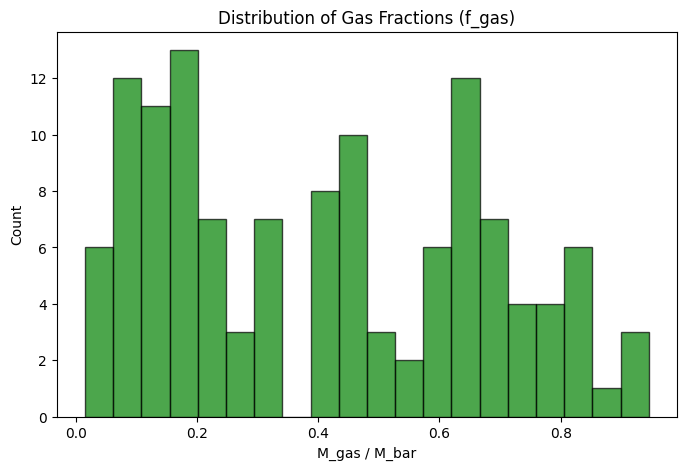

Average f_gas: 0.407
Max f_gas:     0.945


In [ ]:
print('=== Gas Fraction Sanity Check ===')
# Check if MHI was correctly used or if we need to include other gas components
print(sparc_df[['Galaxy', 'MHI', 'M_gas', 'M_bar']].head(10))

# Visualize the distribution of f_gas
plt.figure(figsize=(8, 5))
plt.hist(df['f_gas'], bins=20, color='green', alpha=0.7, edgecolor='black')
plt.title('Distribution of Gas Fractions (f_gas)')
plt.xlabel('M_gas / M_bar')
plt.ylabel('Count')
plt.show()

print(f'Average f_gas: {df["f_gas"].mean():.3f}')
print(f'Max f_gas:     {df["f_gas"].max():.3f}')

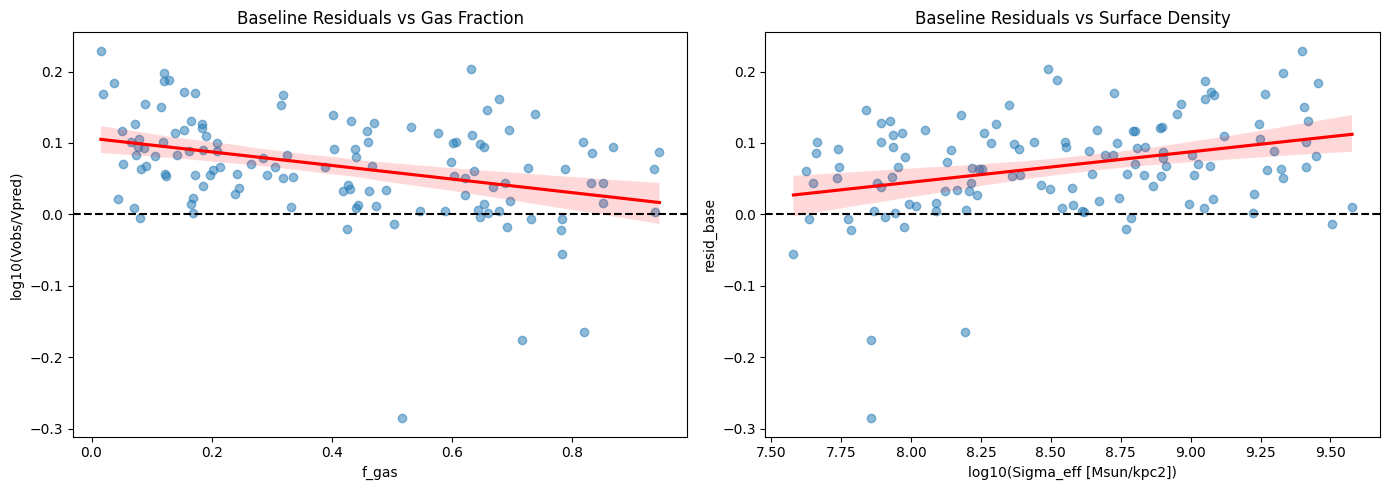

Spearman Correlation (resid vs f_gas): -0.358 (p=0.0000)
Spearman Correlation (resid vs log Sigma): 0.289 (p=0.0011)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the baseline residuals (fixed mu_0)
df_diag = df.copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Gas Fraction
sns.regplot(x='f_gas', y='resid_base', data=df_diag, ax=ax1,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title('Baseline Residuals vs Gas Fraction')
ax1.set_ylabel('log10(Vobs/Vpred)')

# Plot 2: Residuals vs Surface Density
sns.regplot(x=np.log10(df_diag['Sigma_eff']), y='resid_base', data=df_diag, ax=ax2,
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title('Baseline Residuals vs Surface Density')
ax2.set_xlabel('log10(Sigma_eff [Msun/kpc2])')

plt.tight_layout()
plt.show()

from scipy.stats import spearmanr
corr_f, p_f = spearmanr(df_diag['f_gas'], df_diag['resid_base'])
corr_s, p_s = spearmanr(np.log10(df_diag['Sigma_eff']), df_diag['resid_base'])

print(f'Spearman Correlation (resid vs f_gas): {corr_f:.3f} (p={p_f:.4f})')
print(f'Spearman Correlation (resid vs log Sigma): {corr_s:.3f} (p={p_s:.4f})')